# Детекция апноэ по ECG / PPG

- **Фаза 1:** подключение источников данных: Apnea-ECG / PhysioNet, Kaggle-зеркало, MESA через SleepECG.
- **Фаза 2:** предобработка сигналов: нарезка на 1-минутные окна, нормализация, ресэмплинг.
- **Фаза 3:** baseline-модель `ECG only` на 1D CNN.
- **Фаза 4:** каркас transfer learning: предобучение на большом датасете + fine-tuning на Apnea-ECG.
- **Фаза 5:** мультимодальная модель `ECG + PPG` с двумя CNN-энкодерами и fusion.
- **Фаза 6:** SpO2-модель.

## 0. Установка библиотек

In [1]:
!pip3 install numpy pandas scipy scikit-learn torch tqdm matplotlib wfdb sleepecg kagglehub

# Для MESA через SleepECG может дополнительно понадобиться edfio:
!pip3 install -q edfio

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## 1. Импорты и настройки

In [2]:
from pathlib import Path
import os
import json
import math
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Iterable

import numpy as np
import pandas as pd
from scipy.signal import resample_poly
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

/Users/kniazeff/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cpu'

In [ ]:
@dataclass
class Config:
    data_dir: Path = Path('./data')
    cache_dir: Path = Path('./cache')
    artifacts_dir: Path = Path('./artifacts')

    window_sec: int = 60

    target_fs_ecg: int = 100

    target_fs_ppg: int = 25

    batch_size: int = 64
    num_workers: int = 0
    epochs_baseline: int = 10
    epochs_finetune: int = 5
    lr: float = 1e-3
    weight_decay: float = 1e-4

cfg = Config()
for p in [cfg.data_dir, cfg.cache_dir, cfg.artifacts_dir]:
    p.mkdir(parents=True, exist_ok=True)

cfg

Config(data_dir=PosixPath('data'), cache_dir=PosixPath('cache'), artifacts_dir=PosixPath('artifacts'), window_sec=60, target_fs_ecg=100, target_fs_ppg=25, batch_size=64, num_workers=0, epochs_baseline=10, epochs_finetune=5, lr=0.001, weight_decay=0.0001)

# Фаза 1 — данные

Источники:

1. **Kaggle Apnea ECG** — зеркало/вариант Apnea-ECG.
2. **PhysioNet Challenge 2000 / Apnea-ECG** — основной открытый источник, удобнее всего читать через `wfdb`.
3. **SleepECG / MESA** — большой массив, доступ к MESA требует NSRR access request и токен.

Ниже отдельный блок с вариантами загрузки. **Apnea-ECG и MESA действительно можно дергать через функции библиотек**, без ручного скачивания файлов.

## 1.1. Вариант A: Apnea-ECG напрямую из PhysioNet через `wfdb`

Пример чтения одной записи:

```python
record = wfdb.rdrecord('a01', pn_dir='apnea-ecg/1.0.0')
ann = wfdb.rdann('a01', 'apn', pn_dir='apnea-ecg/1.0.0')
```

`rdrecord` читает ECG-сигнал, `rdann` читает минутные разметки апноэ.

In [ ]:
import wfdb

APNEA_PN_DIR = 'apnea-ecg/1.0.0'

APNEA_TRAIN_RECORDS = [
    *(f'a{i:02d}' for i in range(1, 21)),
    *(f'b{i:02d}' for i in range(1, 6)),
    *(f'c{i:02d}' for i in range(1, 11)),
]

APNEA_TEST_RECORDS = [f'x{i:02d}' for i in range(1, 36)] 


def read_apnea_record_physionet(record_name: str):
    """Читает запись Apnea-ECG напрямую с PhysioNet через wfdb."""
    record = wfdb.rdrecord(record_name, pn_dir=APNEA_PN_DIR)
    ann = wfdb.rdann(record_name, 'apn', pn_dir=APNEA_PN_DIR)
    return record, ann

## 1.2. Вариант B: Kaggle-зеркало Apnea ECG

Этот путь удобен, если проект запускается в Kaggle Notebook или если нужно скачать датасет локально через Kaggle API / `kagglehub`.

In [ ]:
def download_apnea_from_kaggle(target_dir: Path = cfg.data_dir / 'kaggle_apnea') -> Path:
    """
    Скачивает Kaggle dataset через kagglehub.

    В PDF дана ссылка: https://www.kaggle.com/datasets/ecerulm/apneaecg
    Kaggle dataset slug обычно имеет вид 'ecerulm/apneaecg'.
    Если slug изменится, поправь строку ниже.
    """
    import kagglehub

    target_dir.mkdir(parents=True, exist_ok=True)
    dataset_path = kagglehub.dataset_download('ecerulm/apneaecg')
    print(f'Downloaded to: {dataset_path}')
    return Path(dataset_path)


# kaggle_path = download_apnea_from_kaggle()

## 1.3. Вариант C: MESA через SleepECG / NSRR token

Требуется:
1. аккаунт NSRR;
2. approved access request к MESA;
3. download token.

После этого SleepECG умеет читать MESA через `read_mesa(...)`; функция возвращает generator.

In [ ]:
def init_nsrr_token(token: Optional[str] = None):
    """
    Инициализация NSRR token для доступа к MESA.

    Можно передать token явно или положить его в переменную окружения NSRR_TOKEN.
    """
    from sleepecg import set_nsrr_token

    token = token or os.getenv('NSRR_TOKEN')
    if token is None:
        raise ValueError(
            'NSRR token не найден. Передай token в init_nsrr_token(token=...) '
            'или установи переменную окружения NSRR_TOKEN.'
        )
    set_nsrr_token(token)
    print('NSRR token initialized')


def iter_mesa_records(records_pattern: str = '00*', data_dir: Path = cfg.data_dir / 'mesa'):
    """
    Generator по MESA через SleepECG.

    records_pattern='00*' берет только первые записи для отладки, чтобы не тянуть весь массив.
    Для полного запуска можно поставить records_pattern='*'.
    """
    from sleepecg import read_mesa

    data_dir.mkdir(parents=True, exist_ok=True)
    return read_mesa(records_pattern=records_pattern, data_dir=str(data_dir))


# init_nsrr_token()  # если NSRR_TOKEN есть в окружении
# mesa_gen = iter_mesa_records(records_pattern='00*')
# first_mesa_record = next(mesa_gen)
# first_mesa_record

# Фаза 2 — предобработка сигналов

Нужно привести сырые сигналы к обучающему формату:

- нарезка на 1-минутные окна;
- метка на каждое окно: `0` = норма, `1` = апноэ;
- нормализация внутри окна;
- при необходимости ресэмплинг к общей частоте.

In [5]:
def z_normalize(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Z-score нормализация для одного окна/сигнала."""
    mean = np.nanmean(x)
    std = np.nanstd(x)
    return (x - mean) / (std + eps)


def resample_to_target_fs(x: np.ndarray, source_fs: int, target_fs: int) -> np.ndarray:
    """Ресэмплинг 1D сигнала через polyphase filtering."""
    if int(source_fs) == int(target_fs):
        return x
    gcd = math.gcd(int(source_fs), int(target_fs))
    up = int(target_fs) // gcd
    down = int(source_fs) // gcd
    return resample_poly(x, up=up, down=down)


def labels_from_apnea_annotation(ann) -> np.ndarray:
    """
    Преобразует WFDB .apn annotation в binary labels.

    Обычно symbol='A' означает apnea, symbol='N' — normal.
    Все не-A метки считаем нормой, но дополнительно печатаем уникальные значения при EDA.
    """
    return np.array([1 if s == 'A' else 0 for s in ann.symbol], dtype=np.int64)


def cut_signal_to_minute_windows(
    signal: np.ndarray,
    fs: int,
    labels: Optional[np.ndarray] = None,
    window_sec: int = 60,
    target_fs: Optional[int] = None,
    normalize: bool = True,
) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """
    Нарезает 1D сигнал на минутные окна.

    Возвращает:
    - X: [n_windows, 1, n_samples]
    - y: [n_windows] или None
    """
    target_fs = target_fs or fs
    samples_per_window_src = int(fs * window_sec)

    n_by_signal = len(signal) // samples_per_window_src
    if labels is not None:
        n_windows = min(n_by_signal, len(labels))
    else:
        n_windows = n_by_signal

    windows = []
    for i in range(n_windows):
        start = i * samples_per_window_src
        end = start + samples_per_window_src
        w = signal[start:end].astype(np.float32)
        w = resample_to_target_fs(w, source_fs=int(fs), target_fs=int(target_fs)).astype(np.float32)
        if normalize:
            w = z_normalize(w).astype(np.float32)
        windows.append(w)

    X = np.stack(windows, axis=0)[:, None, :]  # [N, C=1, T]
    y = labels[:n_windows].astype(np.int64) if labels is not None else None
    return X, y

In [6]:
def build_apnea_ecg_dataset_from_physionet(
    records: List[str] = APNEA_TRAIN_RECORDS,
    cache_path: Path = cfg.cache_dir / 'apnea_ecg_windows_100hz.npz',
    force_rebuild: bool = False,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Собирает обучающий датасет из Apnea-ECG:
    одна строка = одно минутное ECG-окно.

    X shape: [n_windows, 1, 6000] при target_fs=100 и window_sec=60.
    y shape: [n_windows].
    meta: record_name, minute_idx.
    """
    if cache_path.exists() and not force_rebuild:
        arr = np.load(cache_path, allow_pickle=True)
        X = arr['X']
        y = arr['y']
        meta = pd.DataFrame(arr['meta'].tolist())
        print(f'Loaded cache: {cache_path}, X={X.shape}, y={y.shape}')
        return X, y, meta

    X_parts, y_parts, meta_rows = [], [], []

    for rec_name in tqdm(records, desc='Reading Apnea-ECG records'):
        try:
            record, ann = read_apnea_record_physionet(rec_name)
            fs = int(record.fs)
            ecg = record.p_signal[:, 0]
            labels = labels_from_apnea_annotation(ann)

            X_rec, y_rec = cut_signal_to_minute_windows(
                ecg,
                fs=fs,
                labels=labels,
                window_sec=cfg.window_sec,
                target_fs=cfg.target_fs_ecg,
                normalize=True,
            )
            X_parts.append(X_rec)
            y_parts.append(y_rec)
            meta_rows.extend([
                {'record': rec_name, 'minute_idx': i, 'source_fs': fs}
                for i in range(len(y_rec))
            ])
        except Exception as e:
            print(f'Failed record={rec_name}: {e}')

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts, axis=0).astype(np.int64)
    meta = pd.DataFrame(meta_rows)

    np.savez_compressed(cache_path, X=X, y=y, meta=meta.to_dict('records'))
    print(f'Saved cache: {cache_path}, X={X.shape}, y={y.shape}')
    return X, y, meta


# Для первого запуска раскомментируй:
# X_apnea, y_apnea, meta_apnea = build_apnea_ecg_dataset_from_physionet(force_rebuild=False)
# pd.Series(y_apnea).value_counts(normalize=True).rename('share')

## 2.1. Dataset / DataLoader для PyTorch

In [7]:
class SignalDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = 0.2,
    val_size: float = 0.2,
    batch_size: int = cfg.batch_size,
):
    """
    Делит данные на train/val/test стратифицированно по y.
    """
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=SEED,
        stratify=y,
    )
    val_relative = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=val_relative,
        random_state=SEED,
        stratify=y_trainval,
    )

    loaders = {
        'train': DataLoader(SignalDataset(X_train, y_train), batch_size=batch_size, shuffle=True, num_workers=cfg.num_workers),
        'val': DataLoader(SignalDataset(X_val, y_val), batch_size=batch_size, shuffle=False, num_workers=cfg.num_workers),
        'test': DataLoader(SignalDataset(X_test, y_test), batch_size=batch_size, shuffle=False, num_workers=cfg.num_workers),
    }
    splits = {
        'train': (X_train, y_train),
        'val': (X_val, y_val),
        'test': (X_test, y_test),
    }
    return loaders, splits

In [ ]:
# ====================================================================
# ДОПОЛНЕНИЕ ФАЗЫ 2: ФУНКЦИЯ ПРЕПРОЦЕССИНГА ДЛЯ ДАТАСЕТА SHHS
# ====================================================================
import os
import numpy as np
import mne 

def preprocess_shhs_record(edf_path, annotation_path, target_fs=100, window_sec=60):
    """
    Загрузка и нарезка одной записи из датасета SHHS (ECG + SpO2) на 1-минутные окна
    """
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    ch_names = raw.ch_names
    
    ecg_ch = [c for c in ch_names if 'ECG' in c.upper()][0]
    spo2_ch = [c for c in ch_names if 'SAO2' in c.upper() or 'OXYGEN' in c.upper() or 'S区域O2' in c.upper()][0]
    
    raw.resample(target_fs, channels=[ecg_ch, spo2_ch])
    data, _ = raw.get_data(picks=[ecg_ch, spo2_ch])
    
    ecg_signal = data[0]
    spo2_signal = data[1]
    
    total_len_sec = len(ecg_signal) / target_fs
    num_windows = int(total_len_sec // window_sec)
    
    window_labels = np.zeros(num_windows)
    
    if os.path.exists(annotation_path):
        import wfdb
        try:
            ann = wfdb.rdann(annotation_path.replace('.resp', ''), 'resp')
            for sample, sym in zip(ann.sample, ann.symbol):
                sec_idx = sample / ann.fs
                win_idx = int(sec_idx // window_sec)
                if win_idx < num_windows and sym in ['Apnea', 'Hypopnea', 'h', 'a']:
                    window_labels[win_idx] = 1
        except Exception:
            pass 

    ecg_windows, spo2_windows = [], []
    samples_per_window = window_sec * target_fs
    
    for i in range(num_windows):
        start = i * samples_per_window
        end = start + samples_per_window
        
        ecg_w = ecg_signal[start:end]
        spo2_w = spo2_signal[start:end]
        
        if len(ecg_w) == samples_per_window:
            ecg_w = (ecg_w - np.mean(ecg_w)) / (np.std(ecg_w) + 1e-6)
            spo2_w = (spo2_w - np.min(spo2_w)) / (np.max(spo2_w) - np.min(spo2_w) + 1e-6)
            
            ecg_windows.append(ecg_w)
            spo2_windows.append(spo2_w)
            
    return np.array(ecg_windows), np.array(spo2_windows), window_labels[:len(ecg_windows)]

# Фаза 3 — базовая модель ECG only: 1D CNN

Baseline принимает одно 1-минутное окно ECG и предсказывает вероятность апноэ.

In [8]:
class CNN1DEncoder(nn.Module):
    def __init__(self, in_channels: int = 1, embedding_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(128, embedding_dim)

    def forward(self, x):
        h = self.net(x).squeeze(-1)
        z = self.proj(h)
        return z


class ECGOnlyClassifier(nn.Module):
    def __init__(self, embedding_dim: int = 128):
        super().__init__()
        self.encoder = CNN1DEncoder(in_channels=1, embedding_dim=embedding_dim)
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(embedding_dim, 1),
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.classifier(z).squeeze(1)
        return logits

In [9]:
def run_epoch(model, loader, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train(is_train)
    criterion = nn.BCEWithLogitsLoss()

    total_loss = 0.0
    y_true, y_prob = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(yb)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_prob.extend(probs.tolist())
        y_true.extend(yb.detach().cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'loss': total_loss / len(loader.dataset),
        'auroc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        'accuracy': accuracy_score(y_true, y_pred),
    }
    return metrics, y_true, y_prob


def train_model(model, loaders, epochs: int, lr: float = cfg.lr, weight_decay: float = cfg.weight_decay, save_path: Optional[Path] = None):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_auc = -np.inf
    history = []
    best_state = None

    for epoch in range(1, epochs + 1):
        train_metrics, _, _ = run_epoch(model, loaders['train'], optimizer=optimizer)
        val_metrics, _, _ = run_epoch(model, loaders['val'], optimizer=None)

        row = {
            'epoch': epoch,
            **{f'train_{k}': v for k, v in train_metrics.items()},
            **{f'val_{k}': v for k, v in val_metrics.items()},
        }
        history.append(row)
        print(row)

        if val_metrics['auroc'] > best_val_auc:
            best_val_auc = val_metrics['auroc']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if save_path is not None:
                save_path.parent.mkdir(parents=True, exist_ok=True)
                torch.save(best_state, save_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

In [ ]:
X_apnea, y_apnea, meta_apnea = build_apnea_ecg_dataset_from_physionet(force_rebuild=False)
loaders, splits = make_loaders(X_apnea, y_apnea)

baseline_model = ECGOnlyClassifier(embedding_dim=128)
baseline_model, baseline_history = train_model(
    baseline_model,
    loaders,
    epochs=cfg.epochs_baseline,
    save_path=cfg.artifacts_dir / 'baseline_ecg_only.pt',
)

test_metrics, y_true_test, y_prob_test = run_epoch(baseline_model, loaders['test'])
print('TEST:', test_metrics)
print(classification_report(y_true_test, (y_prob_test >= 0.5).astype(int)))

Loaded cache: cache/apnea_ecg_windows_100hz.npz, X=(17023, 1, 6000), y=(17023,)
{'epoch': 1, 'train_loss': 0.45584082689829675, 'train_auroc': 0.8548005316439441, 'train_accuracy': 0.7747968275727014, 'val_loss': 0.38365117938595544, 'val_auroc': 0.9049229649984332, 'val_accuracy': 0.8202643171806168}
{'epoch': 2, 'train_loss': 0.3900868482796555, 'train_auroc': 0.8960859407160016, 'train_accuracy': 0.8144521688044649, 'val_loss': 0.6382259559438792, 'val_auroc': 0.8756567495926015, 'val_accuracy': 0.7283406754772394}
{'epoch': 3, 'train_loss': 0.36570338787405027, 'train_auroc': 0.9105879555679702, 'train_accuracy': 0.8264956428081857, 'val_loss': 0.3502245056340348, 'val_auroc': 0.9195312380163515, 'val_accuracy': 0.8302496328928047}
{'epoch': 4, 'train_loss': 0.34668736067152534, 'train_auroc': 0.9197121206328133, 'train_accuracy': 0.8366787427788113, 'val_loss': 0.33367667892693426, 'val_auroc': 0.9291389741668147, 'val_accuracy': 0.8384728340675477}
{'epoch': 5, 'train_loss': 0.33

baseline_history type: <class 'pandas.core.frame.DataFrame'>


,epoch,train_loss,train_auroc,train_accuracy,val_loss,val_auroc,val_accuracy
0,1,0.455841,0.854801,0.774797,0.383651,0.904923,0.820264
1,2,0.390087,0.896086,0.814452,0.638226,0.875657,0.728341
2,3,0.365703,0.910588,0.826496,0.350225,0.919531,0.830250
3,4,0.346687,0.919712,0.836679,0.333677,0.929139,0.838473
4,5,0.333243,0.926139,0.846274,0.338135,0.925535,0.841410


columns: ['epoch', 'train_loss', 'train_auroc', 'train_accuracy', 'val_loss', 'val_auroc', 'val_accuracy']


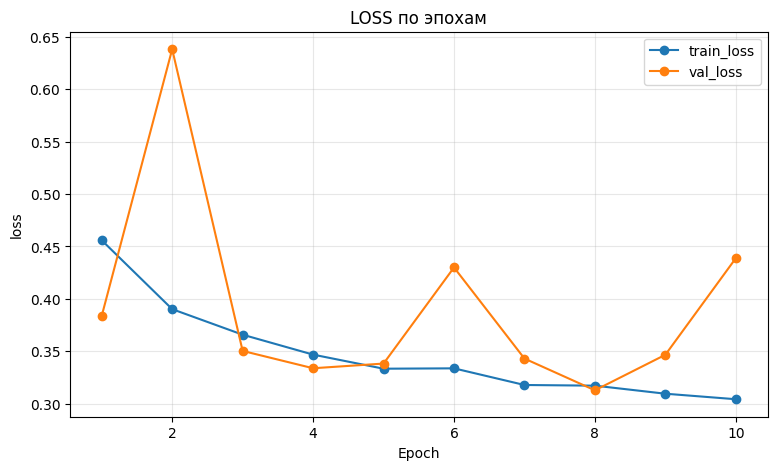

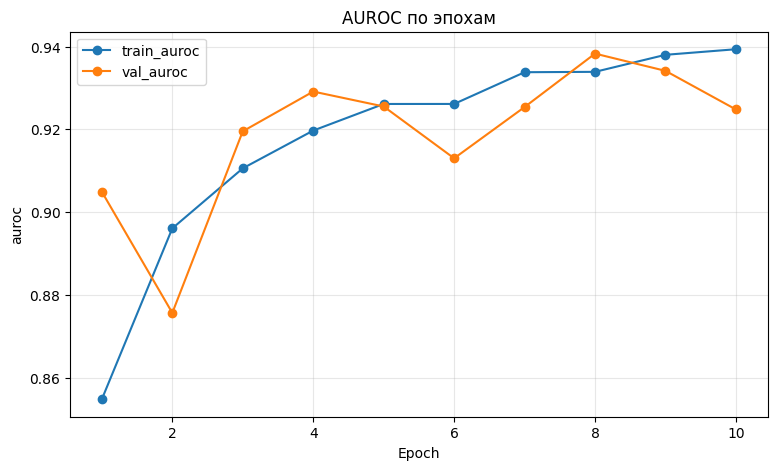

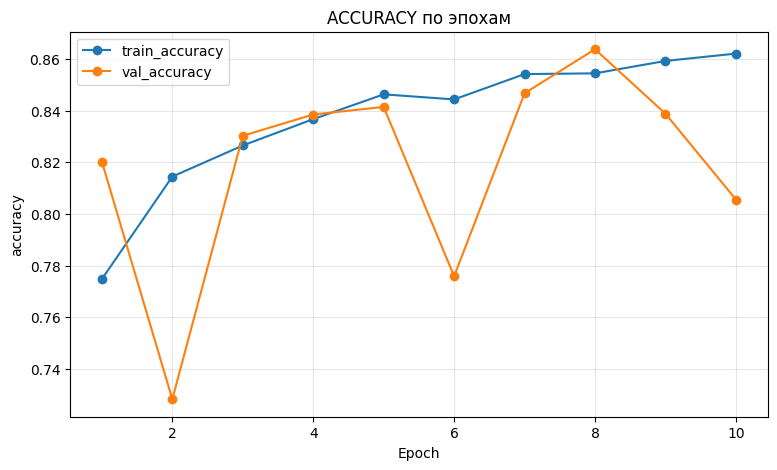

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("baseline_history type:", type(baseline_history))

if isinstance(baseline_history, pd.DataFrame):
    history_df = baseline_history.copy()

elif isinstance(baseline_history, list):
    history_df = pd.DataFrame(baseline_history)

elif isinstance(baseline_history, dict):
    history_df = pd.DataFrame(baseline_history)

elif isinstance(baseline_history, tuple):
    print("baseline_history is tuple, length:", len(baseline_history))
    for i, item in enumerate(baseline_history):
        print(f"item {i}: type={type(item)}")
    
    history_df = None
    
    for item in baseline_history:
        if isinstance(item, pd.DataFrame):
            history_df = item.copy()
            break
        elif isinstance(item, list):
            history_df = pd.DataFrame(item)
            break
        elif isinstance(item, dict):
            history_df = pd.DataFrame(item)
            break
    
    if history_df is None:
        raise TypeError("Внутри baseline_history tuple не нашел list/dict/DataFrame с историей обучения")

else:
    raise TypeError(f"Неизвестный формат baseline_history: {type(baseline_history)}")

display(history_df.head())
print("columns:", history_df.columns.tolist())

if "epoch" not in history_df.columns:
    history_df["epoch"] = range(1, len(history_df) + 1)

metric_groups = {
    "loss": ["train_loss", "val_loss", "test_loss", "loss"],
    "auroc": ["train_auroc", "val_auroc", "test_auroc", "auroc", "roc_auc"],
    "accuracy": ["train_accuracy", "val_accuracy", "test_accuracy", "accuracy", "acc"],
    "f1": ["train_f1", "val_f1", "test_f1", "f1"],
    "precision": ["train_precision", "val_precision", "test_precision", "precision"],
    "recall": ["train_recall", "val_recall", "test_recall", "recall"],
}

plotted_anything = False

for metric_name, possible_cols in metric_groups.items():
    cols = [col for col in possible_cols if col in history_df.columns]
    
    if not cols:
        continue

    plotted_anything = True

    plt.figure(figsize=(9, 5))
    
    for col in cols:
        plt.plot(history_df["epoch"], history_df[col], marker="o", label=col)
    
    plt.title(f"{metric_name.upper()} по эпохам")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

if not plotted_anything:
    print("Не нашел стандартных колонок с метриками.")
    print("Доступные колонки:")
    print(history_df.columns.tolist())

### Следующие этапы после первого baseline

1. честная валидация через **patient-level / record-level split**;
2. графики loss/quality по эпохам;
3. confusion matrix, ROC и PR-кривая;
4. сравнение CNN с простым ML baseline на ручных признаках;
5. эксперименты с архитектурой CNN: shallow / deeper / wider / residual.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, precision_score, recall_score,
    average_precision_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import skew, kurtosis

import matplotlib.pyplot as plt
import gc

# На Mac с Apple Silicon лучше mps, если он доступен.
DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print("DEVICE:", DEVICE)


DEVICE: mps


## Этап A — проверяем, что данные уже есть в памяти

In [14]:
if not all(name in globals() for name in ["X_apnea", "y_apnea", "meta_apnea"]):
    print("X_apnea / y_apnea / meta_apnea не найдены в памяти. Пробую загрузить/собрать датасет...")
    X_apnea, y_apnea, meta_apnea = build_apnea_ecg_dataset_from_physionet(force_rebuild=False)
else:
    print("Данные уже есть в памяти.")

print("X_apnea:", X_apnea.shape)
print("y_apnea:", y_apnea.shape)
print("meta_apnea:", meta_apnea.shape)

display(meta_apnea.head())
display(pd.Series(y_apnea).value_counts().rename(index={0: "normal", 1: "apnea"}).to_frame("count"))
print("records:", meta_apnea["record"].nunique())


Данные уже есть в памяти.
X_apnea: (17023, 1, 6000)
y_apnea: (17023,)
meta_apnea: (17023, 3)


,record,minute_idx,source_fs
0,a01,0,100
1,a01,1,100
2,a01,2,100
3,a01,3,100
4,a01,4,100


,count
normal,10512
apnea,6511


records: 35


## Этап B — честный split по записям / пациентам

Старый split по отдельным минутным окнам может завышать качество: соседние минуты одной ночи очень похожи, и модель может видеть почти такие же фрагменты в train и test.

Cделаем более честный вариант: все окна одной записи попадают только в один split.


In [15]:
def summarize_split(name: str, idx: np.ndarray, y: np.ndarray, meta: pd.DataFrame) -> dict:
    y_part = y[idx]
    records = meta.iloc[idx]["record"].unique()
    return {
        "split": name,
        "n_windows": len(idx),
        "n_records": len(records),
        "apnea_share": float(np.mean(y_part)),
        "normal_windows": int(np.sum(y_part == 0)),
        "apnea_windows": int(np.sum(y_part == 1)),
        "records": ", ".join(records[:10]) + ("..." if len(records) > 10 else ""),
    }


def make_group_loaders(
    X: np.ndarray,
    y: np.ndarray,
    meta: pd.DataFrame,
    group_col: str = "record",
    test_size: float = 0.20,
    val_size: float = 0.20,
    batch_size: int = cfg.batch_size,
):
    """
    Делит данные на train/val/test так, чтобы окна одной записи не попадали в разные части.
    Важно: стратификация по y не гарантируется идеально, потому что делим целыми группами/записями.
    """
    idx = np.arange(len(y))
    groups = meta[group_col].values

    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=SEED)
    trainval_idx, test_idx = next(gss_test.split(idx, y, groups=groups))

    val_relative = val_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative, random_state=SEED)
    train_rel_idx, val_rel_idx = next(
        gss_val.split(trainval_idx, y[trainval_idx], groups=groups[trainval_idx])
    )
    train_idx = trainval_idx[train_rel_idx]
    val_idx = trainval_idx[val_rel_idx]

    loaders = {
        "train": DataLoader(SignalDataset(X[train_idx], y[train_idx]), batch_size=batch_size, shuffle=True, num_workers=cfg.num_workers),
        "val": DataLoader(SignalDataset(X[val_idx], y[val_idx]), batch_size=batch_size, shuffle=False, num_workers=cfg.num_workers),
        "test": DataLoader(SignalDataset(X[test_idx], y[test_idx]), batch_size=batch_size, shuffle=False, num_workers=cfg.num_workers),
    }
    splits = {
        "train": {"idx": train_idx, "X": X[train_idx], "y": y[train_idx]},
        "val": {"idx": val_idx, "X": X[val_idx], "y": y[val_idx]},
        "test": {"idx": test_idx, "X": X[test_idx], "y": y[test_idx]},
    }

    summary = pd.DataFrame([
        summarize_split("train", train_idx, y, meta),
        summarize_split("val", val_idx, y, meta),
        summarize_split("test", test_idx, y, meta),
    ])

    return loaders, splits, summary


group_loaders, group_splits, group_split_summary = make_group_loaders(X_apnea, y_apnea, meta_apnea)
display(group_split_summary)


,split,n_windows,n_records,apnea_share,normal_windows,apnea_windows,records
0,train,10162,21,0.406121,6035,4127,"a02, a03, a04, a05, a06, a07, a08, a11, a12, a..."
1,val,3446,7,0.351712,2234,1212,"a01, a09, a10, a13, b01, c03, c08"
2,test,3415,7,0.343192,2243,1172,"a14, a16, a20, b02, b05, c02, c05"


## Этап C — переобучаем baseline на честном group split

Важный эксперимент. Если качество заметно ниже, чем раньше, это не плохо: это значит, что старая оценка была слишком оптимистичной. Именно group split лучше показывает переносимость модели на новые записи.


In [22]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

# Лучше для Mac временно принудительно CPU, чтобы убрать MPS/NNPack-странности
device = torch.device("cpu")
torch.backends.nnpack.enabled = False

print("Using device:", device)

# Жестко приводим исходные массивы
X_apnea = X_apnea.astype(np.float32)
y_apnea = y_apnea.astype(np.int64)


def run_epoch(model, loader, optimizer=None, criterion=None):
    """
    Robust run_epoch:
    - всегда приводит X к float32
    - y к long / float в зависимости от выхода модели
    - работает и для binary-logit выхода [B, 1], и для multiclass [B, 2]
    """
    is_train = optimizer is not None
    model = model.to(device)

    if is_train:
        model.train()
    else:
        model.eval()

    all_y_true = []
    all_y_prob = []
    losses = []

    for xb, yb in loader:
        xb = xb.to(device=device, dtype=torch.float32)
        yb = yb.to(device=device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(xb)

            # case 1: binary output: [B] или [B, 1]
            if logits.ndim == 1 or logits.shape[-1] == 1:
                logits_flat = logits.view(-1)
                y_float = yb.float().view(-1)

                loss_fn = torch.nn.BCEWithLogitsLoss()
                loss = loss_fn(logits_flat, y_float)

                probs = torch.sigmoid(logits_flat).detach().cpu().numpy()

            # case 2: two-class output: [B, 2]
            else:
                y_long = yb.long().view(-1)

                loss_fn = torch.nn.CrossEntropyLoss()
                loss = loss_fn(logits, y_long)

                probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

            if is_train:
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        all_y_true.extend(yb.detach().cpu().numpy().astype(int).ravel())
        all_y_prob.extend(probs.ravel())

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["auroc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics["auroc"] = np.nan

    return metrics, y_true, y_prob

Using device: cpu


In [23]:
from sklearn.metrics import classification_report

group_col = "record"

group_loaders, group_splits, group_split_summary = make_group_loaders(
    X=X_apnea,
    y=y_apnea,
    meta=meta_apnea,
    group_col=group_col,
)

display(group_split_summary)

xb, yb = next(iter(group_loaders["train"]))
print("X dtype before model:", xb.dtype)
print("y dtype:", yb.dtype)
print("X shape:", xb.shape)

patient_baseline_model = ECGOnlyClassifier(embedding_dim=128).to(device)

patient_baseline_model, patient_baseline_history = train_model(
    patient_baseline_model,
    group_loaders,
    epochs=cfg.epochs_baseline,
    save_path=cfg.artifacts_dir / "baseline_ecg_only_group_split.pt",
)

patient_test_metrics, y_true_group_test, y_prob_group_test = run_epoch(
    patient_baseline_model,
    group_loaders["test"],
)

y_pred_group_test = (y_prob_group_test >= 0.5).astype(int)

print("GROUP-SPLIT TEST:", patient_test_metrics)
print(
    classification_report(
        y_true_group_test,
        y_pred_group_test,
        target_names=["normal", "apnea"],
    )
)

,split,n_windows,n_records,apnea_share,normal_windows,apnea_windows,records
0,train,10162,21,0.406121,6035,4127,"a02, a03, a04, a05, a06, a07, a08, a11, a12, a..."
1,val,3446,7,0.351712,2234,1212,"a01, a09, a10, a13, b01, c03, c08"
2,test,3415,7,0.343192,2243,1172,"a14, a16, a20, b02, b05, c02, c05"


X dtype before model: torch.float32
y dtype: torch.float32
X shape: torch.Size([64, 1, 6000])
{'epoch': 1, 'train_loss': 0.4509545165412831, 'train_accuracy': 0.765597323361543, 'train_precision': 0.6940182343784745, 'train_recall': 0.7562393990792343, 'train_f1': 0.7237940630797773, 'train_auroc': 0.8552079391498868, 'val_loss': 0.4765486019077124, 'val_accuracy': 0.7202553685432386, 'val_precision': 0.5814717477003942, 'val_recall': 0.7301980198019802, 'val_f1': 0.6474030724213606, 'val_auroc': 0.8493903105619425}
{'epoch': 2, 'train_loss': 0.3799534132645565, 'train_accuracy': 0.810371974020862, 'train_precision': 0.748868778280543, 'train_recall': 0.8020353767870123, 'train_f1': 0.7745407745407745, 'train_auroc': 0.9020211234481678, 'val_loss': 0.59283856868192, 'val_accuracy': 0.787579802669762, 'val_precision': 0.9938271604938271, 'val_recall': 0.39851485148514854, 'val_f1': 0.568904593639576, 'val_auroc': 0.8831721578603696}
{'epoch': 3, 'train_loss': 0.3497014189103864, 'train_

## Этап D — графики обучения по эпохам

Смотрим, не переобучается ли модель. Нормальный признак: train и val loss снижаются, а val AUROC не падает после первых эпох.


,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_auroc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auroc
0,1,0.450955,0.765597,0.694018,0.756239,0.723794,0.855208,0.476549,0.720255,0.581472,0.730198,0.647403,0.849390
1,2,0.379953,0.810372,0.748869,0.802035,0.774541,0.902021,0.592839,0.787580,0.993827,0.398515,0.568905,0.883172
2,3,0.349701,0.827495,0.777856,0.805185,0.791285,0.918096,0.753684,0.575160,0.449640,0.928218,0.605816,0.738494
3,4,0.338370,0.838713,0.794090,0.813908,0.803877,0.924435,0.517426,0.777133,0.648198,0.801155,0.716605,0.812739
4,5,0.324755,0.846782,0.804936,0.821905,0.813332,0.930887,0.753918,0.764074,0.624765,0.824257,0.710779,0.749826
5,6,0.309121,0.854950,0.814411,0.832566,0.823388,0.938035,0.821240,0.718224,0.560951,0.915017,0.695516,0.766655
6,7,0.302266,0.863117,0.826648,0.838866,0.832712,0.941739,0.733357,0.771619,0.630288,0.848185,0.723180,0.809507
7,8,0.296598,0.867152,0.829888,0.846378,0.838052,0.944034,0.611053,0.778003,0.638734,0.849010,0.729012,0.855467
8,9,0.288713,0.872564,0.839080,0.849043,0.844032,0.947477,0.982149,0.732443,0.578804,0.878713,0.697903,0.777271
9,10,0.280592,0.878469,0.845272,0.857766,0.851473,0.950565,0.843543,0.770749,0.635256,0.817657,0.715007,0.802955


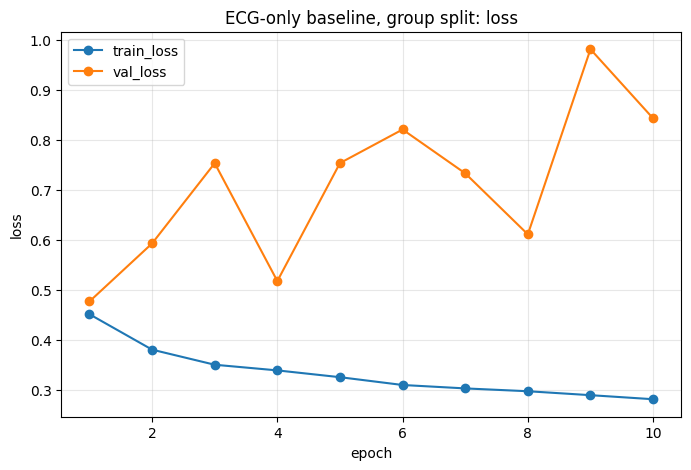

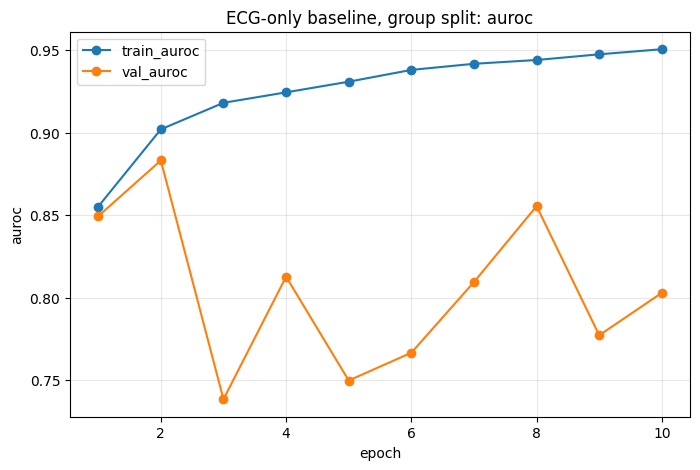

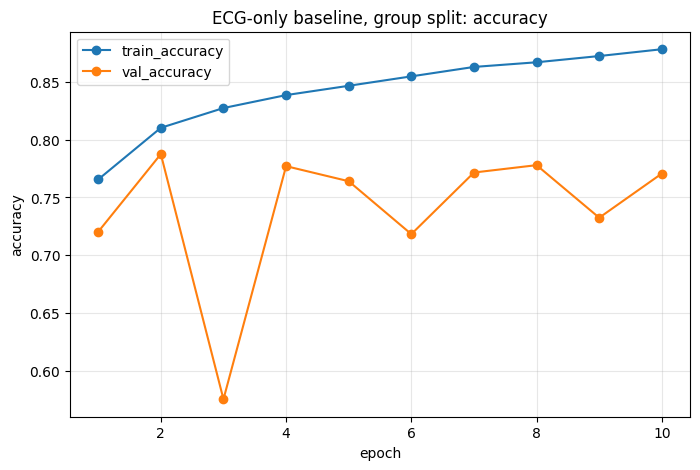

Лучшая эпоха по val_auroc:


,value
epoch,2.000000
train_loss,0.379953
train_accuracy,0.810372
train_precision,0.748869
train_recall,0.802035
train_f1,0.774541
train_auroc,0.902021
val_loss,0.592839
val_accuracy,0.787580
val_precision,0.993827


In [24]:
def plot_training_history(history_df: pd.DataFrame, title: str = "training history"):
    history_df = history_df.copy()
    if "epoch" not in history_df.columns:
        history_df["epoch"] = np.arange(1, len(history_df) + 1)

    display(history_df)

    metric_groups = {
        "loss": ["train_loss", "val_loss"],
        "auroc": ["train_auroc", "val_auroc"],
        "accuracy": ["train_accuracy", "val_accuracy"],
    }

    for metric_name, cols in metric_groups.items():
        cols = [c for c in cols if c in history_df.columns]
        if not cols:
            continue

        plt.figure(figsize=(8, 5))
        for col in cols:
            plt.plot(history_df["epoch"], history_df[col], marker="o", label=col)
        plt.title(f"{title}: {metric_name}")
        plt.xlabel("epoch")
        plt.ylabel(metric_name)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    if "val_auroc" in history_df.columns:
        best_row = history_df.loc[history_df["val_auroc"].idxmax()]
        print("Лучшая эпоха по val_auroc:")
        display(best_row.to_frame("value"))


plot_training_history(patient_baseline_history, title="ECG-only baseline, group split")


## Этап E — confusion matrix, ROC и Precision-Recall

Для медицинской задачи важно смотреть не только accuracy, но и ошибки по классам. Особенно важен recall класса apnea: сколько реальных apnea-окон модель не пропускает.


AUROC: 0.6509169977434537
Average precision: 0.452671172420969
Accuracy: 0.6937042459736457
Precision apnea: 0.5860655737704918
Recall apnea: 0.3660409556313993
F1 apnea: 0.45063025210084034


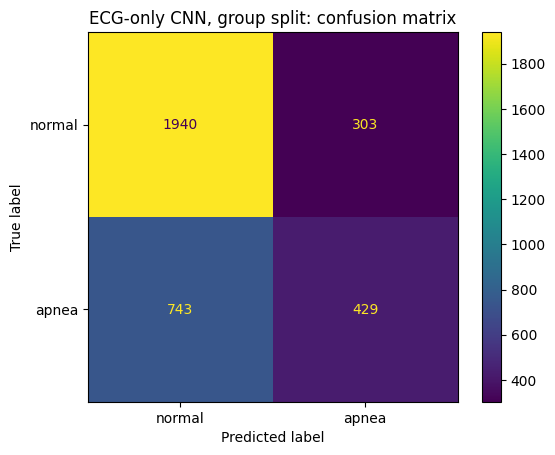

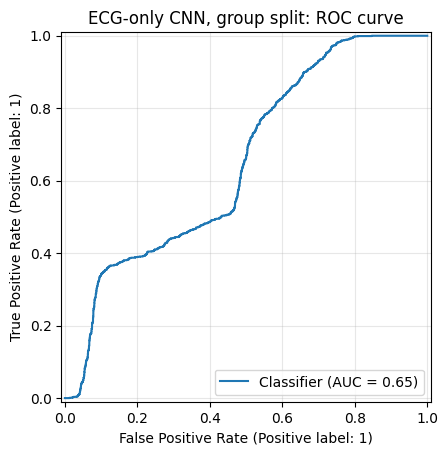

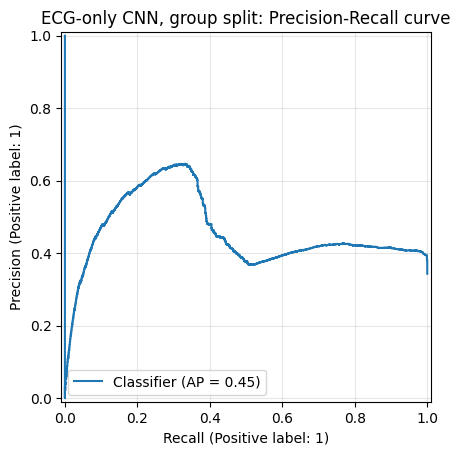

In [25]:
def plot_binary_eval(y_true, y_prob, title: str = "model"):
    y_pred = (y_prob >= 0.5).astype(int)

    print("AUROC:", roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan)
    print("Average precision:", average_precision_score(y_true, y_prob))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision apnea:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall apnea:", recall_score(y_true, y_pred, zero_division=0))
    print("F1 apnea:", f1_score(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "apnea"])
    disp.plot(values_format="d")
    plt.title(f"{title}: confusion matrix")
    plt.show()

    RocCurveDisplay.from_predictions(y_true, y_prob)
    plt.title(f"{title}: ROC curve")
    plt.grid(True, alpha=0.3)
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_true, y_prob)
    plt.title(f"{title}: Precision-Recall curve")
    plt.grid(True, alpha=0.3)
    plt.show()


plot_binary_eval(y_true_group_test, y_prob_group_test, title="ECG-only CNN, group split")


## Этап F — простой ML baseline на ручных признаках

Чтобы CNN не была единственной точкой сравнения, добавим простой baseline на статистических и частотных признаках ECG-окна. Это не полноценные HRV-признаки по R-пикам, но хороший быстрый sanity check.

Если простая модель близка к CNN, значит задача частично решается простыми признаками. Если CNN лучше, это аргумент в пользу обучения по сырому сигналу.


In [26]:
def extract_raw_ecg_features(X: np.ndarray, fs: int = cfg.target_fs_ecg) -> pd.DataFrame:
    """
    Быстрые признаки из raw ECG window.
    X shape: [n, 1, samples]
    """
    x = X[:, 0, :]

    features = {
        "mean": np.mean(x, axis=1),
        "std": np.std(x, axis=1),
        "min": np.min(x, axis=1),
        "max": np.max(x, axis=1),
        "ptp": np.ptp(x, axis=1),
        "median": np.median(x, axis=1),
        "q05": np.quantile(x, 0.05, axis=1),
        "q25": np.quantile(x, 0.25, axis=1),
        "q75": np.quantile(x, 0.75, axis=1),
        "q95": np.quantile(x, 0.95, axis=1),
        "rms": np.sqrt(np.mean(x ** 2, axis=1)),
        "abs_mean": np.mean(np.abs(x), axis=1),
        "skew": skew(x, axis=1, nan_policy="omit"),
        "kurtosis": kurtosis(x, axis=1, nan_policy="omit"),
        "zero_cross_rate": np.mean(np.diff(np.signbit(x), axis=1), axis=1),
    }

    freqs = np.fft.rfftfreq(x.shape[1], d=1 / fs)
    spectrum = np.abs(np.fft.rfft(x, axis=1)) ** 2
    total_power = spectrum.sum(axis=1) + 1e-8

    bands = {
        "pow_0_5_4": (0.5, 4),
        "pow_4_15": (4, 15),
        "pow_15_40": (15, 40),
    }
    for name, (lo, hi) in bands.items():
        mask = (freqs >= lo) & (freqs < hi)
        features[name] = spectrum[:, mask].sum(axis=1) / total_power

    return pd.DataFrame(features).replace([np.inf, -np.inf], np.nan).fillna(0)


X_features = extract_raw_ecg_features(X_apnea)
display(X_features.head())
print(X_features.shape)


,mean,std,min,max,ptp,median,q05,q25,q75,q95,rms,abs_mean,skew,kurtosis,zero_cross_rate,pow_0_5_4,pow_4_15,pow_15_40
0,-4.172325e-09,1.0,-3.464937,6.862296,10.327232,-0.153168,-0.819441,-0.349130,0.160373,1.003012,1.0,0.545934,2.823821,16.244234,0.086181,0.139507,0.572282,0.283274
1,-2.781550e-09,1.0,-3.350235,6.468766,9.819000,-0.133025,-0.839695,-0.356184,0.201714,0.945578,1.0,0.552889,2.682191,14.860634,0.080513,0.135984,0.564728,0.294725
2,-1.192093e-08,1.0,-3.805427,6.434133,10.239560,-0.110362,-0.900849,-0.349346,0.238923,0.900726,1.0,0.551887,2.486454,14.055260,0.109018,0.121458,0.567607,0.302989
3,1.207987e-08,1.0,-4.158470,6.561627,10.720098,-0.122878,-0.869552,-0.336213,0.250459,0.979354,1.0,0.566810,1.920162,11.388732,0.103851,0.130650,0.545215,0.317501
4,-8.106232e-09,1.0,-3.874727,6.358840,10.233566,-0.151729,-0.918779,-0.357523,0.222441,1.026908,1.0,0.576014,2.111701,11.644187,0.079013,0.151458,0.533285,0.309865


(17023, 18)


In [27]:
def evaluate_sklearn_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name: str):
    model.fit(X_train, y_train)

    rows = []
    probs = {}
    for split_name, X_part, y_part in [
        ("train", X_train, y_train),
        ("val", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_part)[:, 1]
        else:
            y_score = model.decision_function(X_part)
            y_prob = 1 / (1 + np.exp(-y_score))
        y_pred = (y_prob >= 0.5).astype(int)
        probs[split_name] = y_prob

        rows.append({
            "model": name,
            "split": split_name,
            "auroc": roc_auc_score(y_part, y_prob) if len(np.unique(y_part)) > 1 else np.nan,
            "accuracy": accuracy_score(y_part, y_pred),
            "precision_apnea": precision_score(y_part, y_pred, zero_division=0),
            "recall_apnea": recall_score(y_part, y_pred, zero_division=0),
            "f1_apnea": f1_score(y_part, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows), probs


train_idx = group_splits["train"]["idx"]
val_idx = group_splits["val"]["idx"]
test_idx = group_splits["test"]["idx"]

Xf_train, yf_train = X_features.iloc[train_idx], y_apnea[train_idx]
Xf_val, yf_val = X_features.iloc[val_idx], y_apnea[val_idx]
Xf_test, yf_test = X_features.iloc[test_idx], y_apnea[test_idx]

sk_models = {
    "logreg_raw_features": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
    "rf_raw_features": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    ),
}

sk_results = []
sk_probs = {}
for name, model in sk_models.items():
    res, probs = evaluate_sklearn_model(model, Xf_train, yf_train, Xf_val, yf_val, Xf_test, yf_test, name)
    sk_results.append(res)
    sk_probs[name] = probs

sk_results_df = pd.concat(sk_results, ignore_index=True)
display(sk_results_df)


,model,split,auroc,accuracy,precision_apnea,recall_apnea,f1_apnea
0,logreg_raw_features,train,0.821442,0.750049,0.656416,0.806882,0.723913
1,logreg_raw_features,val,0.711190,0.534823,0.422081,0.873762,0.569202
2,logreg_raw_features,test,0.630442,0.575988,0.395928,0.447952,0.420336
3,rf_raw_features,train,0.995880,0.965460,0.942569,0.974315,0.958179
4,rf_raw_features,val,0.722133,0.621880,0.460469,0.437294,0.448582
5,rf_raw_features,test,0.691001,0.688141,0.687719,0.167235,0.269046


## Этап G — эксперименты с архитектурой CNN

Проверяем гипотезу: «если просто увеличить число слоев, качество станет лучше».

Важно: это не всегда правда. Более глубокая сеть может лучше извлекать сложные паттерны, но на маленьком датасете она также может быстрее переобучаться. Поэтому сравниваем несколько архитектур на одном и том же group split.


In [28]:
class FlexibleCNN1DEncoder(nn.Module):
    def __init__(
        self,
        channels: List[int],
        kernels: List[int],
        in_channels: int = 1,
        embedding_dim: int = 128,
        dropout: float = 0.1,
    ):
        super().__init__()
        assert len(channels) == len(kernels)

        layers = []
        c_in = in_channels
        for i, (c_out, k) in enumerate(zip(channels, kernels)):
            layers.extend([
                nn.Conv1d(c_in, c_out, kernel_size=k, padding=k // 2),
                nn.BatchNorm1d(c_out),
                nn.ReLU(),
            ])
            if i % 2 == 1:
                layers.append(nn.MaxPool1d(2))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            c_in = c_out

        layers.append(nn.AdaptiveAvgPool1d(1))
        self.net = nn.Sequential(*layers)
        self.proj = nn.Linear(channels[-1], embedding_dim)

    def forward(self, x):
        h = self.net(x).squeeze(-1)
        return self.proj(h)


class FlexibleECGClassifier(nn.Module):
    def __init__(self, encoder: nn.Module, embedding_dim: int = 128, dropout: float = 0.2):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, 1),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.classifier(z).squeeze(1)


In [29]:
class ResidualBlock1D(nn.Module):
    def __init__(self, channels: int, kernel_size: int = 5, dropout: float = 0.1):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(x + self.block(x))


class SmallResNet1DEncoder(nn.Module):
    def __init__(self, in_channels: int = 1, base_channels: int = 64, embedding_dim: int = 128, dropout: float = 0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.stage1 = nn.Sequential(
            ResidualBlock1D(base_channels, kernel_size=5, dropout=dropout),
            ResidualBlock1D(base_channels, kernel_size=5, dropout=dropout),
            nn.MaxPool1d(2),
        )
        self.stage2_proj = nn.Sequential(
            nn.Conv1d(base_channels, base_channels * 2, kernel_size=1),
            nn.BatchNorm1d(base_channels * 2),
            nn.ReLU(),
        )
        self.stage2 = nn.Sequential(
            ResidualBlock1D(base_channels * 2, kernel_size=3, dropout=dropout),
            ResidualBlock1D(base_channels * 2, kernel_size=3, dropout=dropout),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(base_channels * 2, embedding_dim)

    def forward(self, x):
        h = self.stem(x)
        h = self.stage1(h)
        h = self.stage2_proj(h)
        h = self.stage2(h).squeeze(-1)
        return self.proj(h)


In [30]:
def make_architecture_model(name: str, embedding_dim: int = 128) -> nn.Module:
    if name == "baseline_original":
        return ECGOnlyClassifier(embedding_dim=embedding_dim)

    if name == "cnn_shallow":
        encoder = FlexibleCNN1DEncoder(
            channels=[32, 64, 128],
            kernels=[7, 5, 3],
            embedding_dim=embedding_dim,
            dropout=0.05,
        )
        return FlexibleECGClassifier(encoder, embedding_dim=embedding_dim, dropout=0.2)

    if name == "cnn_deeper":
        encoder = FlexibleCNN1DEncoder(
            channels=[32, 32, 64, 64, 128, 128, 256, 256],
            kernels=[7, 7, 5, 5, 5, 3, 3, 3],
            embedding_dim=embedding_dim,
            dropout=0.15,
        )
        return FlexibleECGClassifier(encoder, embedding_dim=embedding_dim, dropout=0.3)

    if name == "cnn_wider":
        encoder = FlexibleCNN1DEncoder(
            channels=[64, 128, 128, 256, 256],
            kernels=[9, 7, 5, 5, 3],
            embedding_dim=embedding_dim,
            dropout=0.15,
        )
        return FlexibleECGClassifier(encoder, embedding_dim=embedding_dim, dropout=0.3)

    if name == "resnet_small":
        encoder = SmallResNet1DEncoder(base_channels=64, embedding_dim=embedding_dim, dropout=0.1)
        return FlexibleECGClassifier(encoder, embedding_dim=embedding_dim, dropout=0.25)

    raise ValueError(f"Unknown architecture: {name}")


ARCHITECTURES = [
    "baseline_original",
    "cnn_shallow",
    "cnn_deeper",
    "cnn_wider",
    "resnet_small",
]


In [ ]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def run_architecture_experiments(
    loaders,
    architectures: List[str] = ARCHITECTURES,
    epochs: Optional[int] = None,
    lr: float = cfg.lr,
    weight_decay: float = cfg.weight_decay,
):
    """
    Обучает несколько архитектур на одном group split и сравнивает качество на test.
    """
    if epochs is None:
        epochs = min(cfg.epochs_baseline, 10)

    rows = []
    histories = {}
    trained_models = {}

    for arch in architectures:
        print("=" * 80)
        print(f"Architecture: {arch}")

        torch.manual_seed(SEED)
        np.random.seed(SEED)

        model = make_architecture_model(arch)
        n_params = count_trainable_params(model)
        print("trainable params:", n_params)

        save_path = cfg.artifacts_dir / f"arch_{arch}_group_split.pt"
        model, hist = train_model(
            model,
            loaders,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            save_path=save_path,
        )

        test_metrics, y_true, y_prob = run_epoch(model, loaders["test"])
        y_pred = (y_prob >= 0.5).astype(int)

        row = {
            "architecture": arch,
            "params": n_params,
            "epochs": epochs,
            "best_val_auroc": float(hist["val_auroc"].max()) if "val_auroc" in hist.columns else np.nan,
            "test_loss": test_metrics["loss"],
            "test_auroc": test_metrics["auroc"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision_apnea": precision_score(y_true, y_pred, zero_division=0),
            "test_recall_apnea": recall_score(y_true, y_pred, zero_division=0),
            "test_f1_apnea": f1_score(y_true, y_pred, zero_division=0),
        }
        rows.append(row)
        histories[arch] = hist
        trained_models[arch] = model

        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    results = pd.DataFrame(rows).sort_values("test_auroc", ascending=False)
    return results, histories, trained_models


# Для быстрого первого запуска можно поставить epochs=5.
# Для финального сравнения лучше epochs=cfg.epochs_baseline или 15-20.
arch_results, arch_histories, arch_models = run_architecture_experiments(
    group_loaders,
    architectures=ARCHITECTURES,
    epochs=min(cfg.epochs_baseline, 10),
)

display(arch_results)


Architecture: baseline_original
trainable params: 118273
{'epoch': 1, 'train_loss': 0.446002592080794, 'train_accuracy': 0.7773076166109034, 'train_precision': 0.7081286288521661, 'train_recall': 0.7683547370971651, 'train_f1': 0.737013364323068, 'train_auroc': 0.8606418137955858, 'val_loss': 0.6200927349704283, 'val_accuracy': 0.6491584445734184, 'val_precision': 0.5007503751875938, 'val_recall': 0.8259075907590759, 'val_f1': 0.6234817813765182, 'val_auroc': 0.7719119606678663}
{'epoch': 2, 'train_loss': 0.37363265848384714, 'train_accuracy': 0.8081086400314899, 'train_precision': 0.7464342313787639, 'train_recall': 0.7988853889023504, 'train_f1': 0.7717696629213483, 'train_auroc': 0.9046334794066353, 'val_loss': 0.9062575424710909, 'val_accuracy': 0.5087057457922228, 'val_precision': 0.41480694296847326, 'val_recall': 0.9661716171617162, 'val_f1': 0.5804213135068154, 'val_auroc': 0.7435751408623404}
{'epoch': 3, 'train_loss': 0.3554290597731212, 'train_accuracy': 0.8227711080495965, 

In [ ]:
def plot_architecture_comparison(arch_results: pd.DataFrame):
    display(arch_results)

    metrics_to_plot = ["test_auroc", "test_f1_apnea", "test_recall_apnea", "test_accuracy"]
    for metric in metrics_to_plot:
        if metric not in arch_results.columns:
            continue
        df_plot = arch_results.sort_values(metric, ascending=True)
        plt.figure(figsize=(9, 5))
        plt.barh(df_plot["architecture"], df_plot[metric])
        plt.title(metric)
        plt.xlabel(metric)
        plt.grid(True, axis="x", alpha=0.3)
        plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(arch_results["params"], arch_results["test_auroc"])
    for _, row in arch_results.iterrows():
        plt.annotate(row["architecture"], (row["params"], row["test_auroc"]), fontsize=9)
    plt.xscale("log")
    plt.xlabel("trainable params, log scale")
    plt.ylabel("test AUROC")
    plt.title("Сложность модели vs качество")
    plt.grid(True, alpha=0.3)
    plt.show()


plot_architecture_comparison(arch_results)


In [ ]:
# Сравнение историй обучения архитектур по val AUROC и val loss
for metric in ["val_auroc", "val_loss"]:
    plt.figure(figsize=(9, 5))
    for arch, hist in arch_histories.items():
        if metric in hist.columns:
            plt.plot(hist["epoch"], hist[metric], marker="o", label=arch)
    plt.title(f"Architecture comparison: {metric}")
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## Этап H — итоговая таблица: CNN vs простые признаки

Эта таблица нужна для отчета: она показывает, насколько raw-signal CNN выигрывает у простых признаков на одинаковом честном split.


In [ ]:
cnn_rows = []

cnn_rows.append({
    "model": "cnn_baseline_group_split",
    "split": "test",
    "auroc": roc_auc_score(y_true_group_test, y_prob_group_test) if len(np.unique(y_true_group_test)) > 1 else np.nan,
    "accuracy": accuracy_score(y_true_group_test, y_pred_group_test),
    "precision_apnea": precision_score(y_true_group_test, y_pred_group_test, zero_division=0),
    "recall_apnea": recall_score(y_true_group_test, y_pred_group_test, zero_division=0),
    "f1_apnea": f1_score(y_true_group_test, y_pred_group_test, zero_division=0),
})

for _, row in arch_results.iterrows():
    cnn_rows.append({
        "model": row["architecture"],
        "split": "test",
        "auroc": row["test_auroc"],
        "accuracy": row["test_accuracy"],
        "precision_apnea": row["test_precision_apnea"],
        "recall_apnea": row["test_recall_apnea"],
        "f1_apnea": row["test_f1_apnea"],
    })

cnn_results_df = pd.DataFrame(cnn_rows)

final_comparison = pd.concat([
    sk_results_df.query("split == 'test'"),
    cnn_results_df,
], ignore_index=True).sort_values("auroc", ascending=False)

display(final_comparison)

plt.figure(figsize=(10, 5))
df_plot = final_comparison.sort_values("auroc", ascending=True)
plt.barh(df_plot["model"], df_plot["auroc"])
plt.xlabel("test AUROC")
plt.title("Итоговое сравнение моделей на group split")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


### Следующий этап — обучение на нескольких датасетах и разных модальностях

Цель блока — расширить проект без MESA/NSRR: использовать открытые датасеты с ECG, SpO2 и respiratory-сигналами.

Что добавляется:
- единый формат `bundle` для разных датасетов и модальностей;
- UCDDB / PhysioNet: ECG + SpO2 + airflow/ribcage/abdomen;
- Mendeley HuGCDN2014-OXI: ECG + SpO2 после ручного скачивания;
- единая flexible CNN, которая обучается на `ECG only`, `SpO2 only`, `ECG + SpO2`, `ECG + SpO2 + respiratory`;
- cross-dataset эксперименты: train на одном датасете, test на другом.

In [ ]:
# Дополнительные библиотеки для EDF/мат-файлов.

!pip3 install -q mne scipy openpyxl

In [ ]:
import re
import urllib.request
from scipy.io import loadmat

try:
    import mne
except ImportError:
    mne = None
    print("mne не установлен. Для UCDDB EDF/REC файлов выполни: !pip install -q mne")


def safe_resample_1d(x: np.ndarray, fs_from: float, fs_to: int) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    if int(round(fs_from)) == int(round(fs_to)):
        return x.astype(np.float32)
    gcd = math.gcd(int(round(fs_from)), int(round(fs_to)))
    up = int(round(fs_to)) // gcd
    down = int(round(fs_from)) // gcd
    return resample_poly(x, up, down).astype(np.float32)


def normalize_1d(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return ((x - np.nanmean(x)) / (np.nanstd(x) + eps)).astype(np.float32)


def cut_1d_to_labeled_windows(signal, fs, labels_per_minute, target_fs, window_sec=60, normalize=True):
    signal = np.asarray(signal, dtype=np.float32)
    n_minutes = len(labels_per_minute)
    samples_per_window = int(round(fs * window_sec))
    windows = []

    for i in range(n_minutes):
        start = i * samples_per_window
        end = start + samples_per_window
        if end > len(signal):
            break
        w = signal[start:end]
        w = safe_resample_1d(w, fs_from=fs, fs_to=target_fs)
        expected_len = window_sec * target_fs
        if len(w) < expected_len:
            w = np.pad(w, (0, expected_len - len(w)))
        elif len(w) > expected_len:
            w = w[:expected_len]
        if normalize:
            w = normalize_1d(w)
        windows.append(w[None, :])

    return np.stack(windows).astype(np.float32)


def plot_multimodal_history(history_df, title_prefix=""):
    display(history_df.head())
    for metric in ["loss", "auroc", "accuracy"]:
        cols = [c for c in history_df.columns if c.endswith(metric)]
        if not cols:
            continue
        plt.figure(figsize=(9, 5))
        for c in cols:
            plt.plot(history_df["epoch"], history_df[c], marker="o", label=c)
        plt.title(f"{title_prefix} {metric.upper()} by epoch".strip())
        plt.xlabel("epoch")
        plt.ylabel(metric)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

## Универсальный формат мультимодального датасета

Каждый источник приводим к формату:

```python
bundle = {
    "modalities": {
        "ecg": X_ecg,       # [n_windows, 1, n_samples]
        "spo2": X_spo2,
        "airflow": X_airflow,
    },
    "y": y,                 # [n_windows]
    "meta": meta_df          # dataset, record, minute_idx
}
```

In [ ]:
class MultiModalWindowsDataset(Dataset):
    def __init__(self, modalities: Dict[str, np.ndarray], y: np.ndarray):
        self.modalities = {k: torch.tensor(v, dtype=torch.float32) for k, v in modalities.items()}
        self.y = torch.tensor(y, dtype=torch.float32)
        n = len(self.y)
        for k, v in self.modalities.items():
            assert len(v) == n, f"{k}: len={len(v)} != y len={n}"

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.modalities.items()}, self.y[idx]


def make_multimodal_group_loaders_v2(modalities, y, meta, group_col="record", test_size=0.20, val_size=0.20, batch_size=cfg.batch_size):
    idx = np.arange(len(y))
    groups = meta[group_col].astype(str).values

    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=SEED)
    trainval_idx, test_idx = next(gss_test.split(idx, y, groups=groups))

    val_relative = val_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative, random_state=SEED)
    train_rel_idx, val_rel_idx = next(gss_val.split(trainval_idx, y[trainval_idx], groups=groups[trainval_idx]))
    train_idx = trainval_idx[train_rel_idx]
    val_idx = trainval_idx[val_rel_idx]

    def slice_modalities(ix):
        return {k: v[ix] for k, v in modalities.items()}

    loaders = {
        "train": DataLoader(MultiModalWindowsDataset(slice_modalities(train_idx), y[train_idx]), batch_size=batch_size, shuffle=True, num_workers=cfg.num_workers),
        "val": DataLoader(MultiModalWindowsDataset(slice_modalities(val_idx), y[val_idx]), batch_size=batch_size, shuffle=False, num_workers=cfg.num_workers),
        "test": DataLoader(MultiModalWindowsDataset(slice_modalities(test_idx), y[test_idx]), batch_size=batch_size, shuffle=False, num_workers=cfg.num_workers),
    }

    summary = pd.DataFrame([
        summarize_split("train", train_idx, y, meta),
        summarize_split("val", val_idx, y, meta),
        summarize_split("test", test_idx, y, meta),
    ])

    return loaders, {"train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx}, summary


def subset_bundle_modalities(bundle: dict, selected_modalities: List[str]) -> dict:
    missing = [m for m in selected_modalities if m not in bundle["modalities"]]
    if missing:
        raise ValueError(f"Нет модальностей {missing}. Доступно: {list(bundle['modalities'].keys())}")
    return {
        "modalities": {m: bundle["modalities"][m] for m in selected_modalities},
        "y": bundle["y"],
        "meta": bundle["meta"].copy(),
    }


def concat_bundles(bundles: List[dict]) -> dict:
    if not bundles:
        raise ValueError("empty bundles")
    common_modalities = set(bundles[0]["modalities"].keys())
    for b in bundles[1:]:
        common_modalities &= set(b["modalities"].keys())
    common_modalities = sorted(common_modalities)
    if not common_modalities:
        raise ValueError("Нет общих модальностей между bundles")

    modalities = {m: np.concatenate([b["modalities"][m] for b in bundles], axis=0).astype(np.float32) for m in common_modalities}
    y = np.concatenate([b["y"] for b in bundles], axis=0).astype(np.int64)
    meta = pd.concat([b["meta"] for b in bundles], ignore_index=True)
    return {"modalities": modalities, "y": y, "meta": meta}

In [ ]:
class FlexibleMultiModalClassifier(nn.Module):
    def __init__(self, modality_names: List[str], embedding_dim: int = 128, hidden_dim: int = 128, dropout: float = 0.25):
        super().__init__()
        self.modality_names = modality_names
        self.encoders = nn.ModuleDict({
            name: CNN1DEncoder(in_channels=1, embedding_dim=embedding_dim)
            for name in modality_names
        })
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim * len(modality_names), hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x_dict: Dict[str, torch.Tensor]):
        z = torch.cat([self.encoders[name](x_dict[name]) for name in self.modality_names], dim=1)
        return self.classifier(z).squeeze(1)


def run_epoch_flexible_multimodal(model, loader, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train(is_train)
    criterion = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    y_true, y_prob = [], []

    for xb, yb in loader:
        xb = {k: v.to(device) for k, v in xb.items()}
        yb = yb.to(device)
        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * len(yb)
        y_prob.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
        y_true.extend(yb.detach().cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "loss": total_loss / len(loader.dataset),
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
    }, y_true, y_prob


def train_flexible_multimodal_model(model, loaders, epochs: int, lr: float = cfg.lr, weight_decay: float = cfg.weight_decay, save_path: Optional[Path] = None):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val_auc = -np.inf
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        train_metrics, _, _ = run_epoch_flexible_multimodal(model, loaders["train"], optimizer=optimizer)
        val_metrics, _, _ = run_epoch_flexible_multimodal(model, loaders["val"])
        row = {
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)
        print(row)
        val_auc = val_metrics.get("auroc", np.nan)
        if np.isfinite(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if save_path is not None:
                save_path.parent.mkdir(parents=True, exist_ok=True)
                torch.save(best_state, save_path)

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

## Датасет 1: Apnea-ECG как ECG-only bundle

Это контрольная точка, чтобы сравнивать старый baseline и новые датасеты в одном формате.

In [ ]:
if not all(name in globals() for name in ["X_apnea", "y_apnea", "meta_apnea"]):
    X_apnea, y_apnea, meta_apnea = build_apnea_ecg_dataset_from_physionet(force_rebuild=False)

apnea_ecg_bundle = {
    "modalities": {"ecg": X_apnea.astype(np.float32)},
    "y": y_apnea.astype(np.int64),
    "meta": meta_apnea.assign(dataset="apnea_ecg").copy(),
}

print(apnea_ecg_bundle["modalities"]["ecg"].shape, apnea_ecg_bundle["y"].shape)
display(apnea_ecg_bundle["meta"].head())

## Датасет 2: UCDDB / PhysioNet — ECG + SpO2 + respiratory

Сначала скачиваем 2–3 записи для smoke-test. `.rec` в UCDDB читается как EDF через `mne`. Разметку apnea/hypopnea берем из `_respevt.txt` и переводим в поминутный таргет.

In [ ]:
UCDDB_BASE_URL = "https://physionet.org/files/ucddb/1.0.0"
UCDDB_DIR = cfg.data_dir / "ucddb"
UCDDB_DIR.mkdir(parents=True, exist_ok=True)
UCDDB_RECORD_IDS = ["ucddb002", "ucddb003", "ucddb005"]


def download_file_if_missing(url: str, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.stat().st_size > 0:
        return path
    print(f"Downloading {url} -> {path}")
    urllib.request.urlretrieve(url, path)
    return path


def download_ucddb_subset(record_ids: List[str] = UCDDB_RECORD_IDS, include_lifecard: bool = False):
    for rid in tqdm(record_ids, desc="Downloading UCDDB subset"):
        download_file_if_missing(f"{UCDDB_BASE_URL}/{rid}.rec", UCDDB_DIR / f"{rid}.rec")
        download_file_if_missing(f"{UCDDB_BASE_URL}/{rid}_respevt.txt", UCDDB_DIR / f"{rid}_respevt.txt")
        download_file_if_missing(f"{UCDDB_BASE_URL}/{rid}_stage.txt", UCDDB_DIR / f"{rid}_stage.txt")
        if include_lifecard:
            download_file_if_missing(f"{UCDDB_BASE_URL}/{rid}_lifecard.edf", UCDDB_DIR / f"{rid}_lifecard.edf")


def inspect_ucddb_record(record_id: str):
    if mne is None:
        raise ImportError("mne не установлен")
    path = UCDDB_DIR / f"{record_id}.rec"
    if not path.exists():
        raise FileNotFoundError(f"Нет файла {path}. Сначала запусти download_ucddb_subset(...)")
    raw = mne.io.read_raw_edf(path, preload=False, verbose=False)
    rows = [{"channel": ch, "type": typ, "sfreq": raw.info["sfreq"]} for ch, typ in zip(raw.ch_names, raw.get_channel_types())]
    print("duration_sec:", raw.times[-1])
    return pd.DataFrame(rows)

# Первый запуск:
download_ucddb_subset(UCDDB_RECORD_IDS, include_lifecard=False)
display(inspect_ucddb_record("ucddb002"))

In [ ]:
def parse_hhmmss_to_seconds(t: str) -> int:
    h, m, s = map(int, t.split(":"))
    return h * 3600 + m * 60 + s


def parse_ucddb_respiratory_events(path: Path) -> pd.DataFrame:
    text = path.read_text(errors="ignore")
    pattern = re.compile(r"(\d{2}:\d{2}:\d{2})\s+([A-Z]+-[A-Z])\s+(\d+)")
    rows = []
    for m in pattern.finditer(text):
        start_time, event_type, duration = m.groups()
        rows.append({
            "start_time": start_time,
            "start_sec": parse_hhmmss_to_seconds(start_time),
            "event_type": event_type,
            "duration_sec": int(duration),
            "is_apnea_like": int(event_type.startswith("APNEA") or event_type.startswith("HYP")),
        })
    return pd.DataFrame(rows)


def ucddb_minute_labels_from_events(events: pd.DataFrame, duration_sec: float, window_sec: int = 60) -> np.ndarray:
    n_minutes = int(duration_sec // window_sec)
    y = np.zeros(n_minutes, dtype=np.int64)
    for _, row in events.iterrows():
        if row["is_apnea_like"] != 1:
            continue
        start = int(row["start_sec"])
        end = start + int(row["duration_sec"])
        start_min = max(0, start // window_sec)
        end_min = min(n_minutes - 1, end // window_sec)
        y[start_min:end_min + 1] = 1
    return y

# Проверка после скачивания:
ev = parse_ucddb_respiratory_events(UCDDB_DIR / "ucddb002_respevt.txt")
display(ev.head())
print(ev["event_type"].value_counts().head())

In [ ]:
def pick_channel(ch_names: List[str], patterns: List[str]) -> Optional[str]:
    low = {ch.lower(): ch for ch in ch_names}
    for pat in patterns:
        for ch_low, ch_orig in low.items():
            if pat.lower() in ch_low:
                return ch_orig
    return None

UCDDB_CHANNEL_PATTERNS = {
    "ecg": ["ecg", "ekg"],
    "spo2": ["spo2", "sao2", "oxygen", "oxim"],
    "airflow": ["flow", "airflow", "oro", "nasal", "therm"],
    "ribcage": ["rib", "thor", "chest"],
    "abdomen": ["abd"],
}
UCDDB_TARGET_FS = {"ecg": cfg.target_fs_ecg, "spo2": 25, "airflow": 25, "ribcage": 25, "abdomen": 25}


def read_ucddb_record_as_bundle(record_id: str, modalities: List[str] = ["ecg", "spo2"]):
    if mne is None:
        raise ImportError("mne не установлен")
    rec_path = UCDDB_DIR / f"{record_id}.rec"
    evt_path = UCDDB_DIR / f"{record_id}_respevt.txt"
    if not rec_path.exists() or not evt_path.exists():
        raise FileNotFoundError(f"Нет {rec_path} или {evt_path}. Сначала скачай запись.")

    raw = mne.io.read_raw_edf(rec_path, preload=True, verbose=False)
    events = parse_ucddb_respiratory_events(evt_path)
    y = ucddb_minute_labels_from_events(events, duration_sec=raw.times[-1], window_sec=cfg.window_sec)

    out_modalities, used_channels = {}, {}
    for mod in modalities:
        ch = pick_channel(raw.ch_names, UCDDB_CHANNEL_PATTERNS.get(mod, [mod]))
        if ch is None:
            print(f"[{record_id}] channel for {mod} not found. Available: {raw.ch_names}")
            continue
        sig = raw.get_data(picks=[ch])[0].astype(np.float32)
        X_mod = cut_1d_to_labeled_windows(sig, fs=float(raw.info["sfreq"]), labels_per_minute=y, target_fs=UCDDB_TARGET_FS.get(mod, 25), window_sec=cfg.window_sec)
        n = min(len(X_mod), len(y))
        out_modalities[mod] = X_mod[:n]
        used_channels[mod] = ch

    if not out_modalities:
        raise ValueError(f"Для {record_id} не удалось прочитать ни одной модальности")
    n = min([len(v) for v in out_modalities.values()] + [len(y)])
    out_modalities = {k: v[:n] for k, v in out_modalities.items()}
    y = y[:n]
    meta = pd.DataFrame({"dataset": "ucddb", "record": record_id, "minute_idx": np.arange(n)})
    for mod, ch in used_channels.items():
        meta[f"channel_{mod}"] = ch
    return {"modalities": out_modalities, "y": y.astype(np.int64), "meta": meta}


def build_ucddb_bundle(record_ids=UCDDB_RECORD_IDS, modalities=["ecg", "spo2"], force_rebuild=False, cache_path=cfg.cache_dir / "ucddb_multimodal_bundle.npz"):
    if cache_path.exists() and not force_rebuild:
        arr = np.load(cache_path, allow_pickle=True)
        return {"modalities": arr["modalities"].item(), "y": arr["y"], "meta": pd.DataFrame(arr["meta"].tolist())}

    bundles = []
    for rid in tqdm(record_ids, desc="Building UCDDB bundle"):
        try:
            b = read_ucddb_record_as_bundle(rid, modalities=modalities)
            print(rid, {k: v.shape for k, v in b["modalities"].items()}, "apnea_share", b["y"].mean())
            bundles.append(b)
        except Exception as e:
            print(f"[ERROR] {rid}: {type(e).__name__}: {e}")

    bundle = concat_bundles(bundles)
    np.savez_compressed(cache_path, modalities=bundle["modalities"], y=bundle["y"], meta=bundle["meta"].to_dict("records"))
    return bundle

# Сборка ECG+SpO2:
ucddb_bundle = build_ucddb_bundle(record_ids=UCDDB_RECORD_IDS, modalities=["ecg", "spo2"], force_rebuild=False)
print({k: v.shape for k, v in ucddb_bundle["modalities"].items()})
display(ucddb_bundle["meta"].head())

## Датасет 3: Mendeley HuGCDN2014-OXI — ECG + SpO2

Скачай и распакуй датасет в `./data/mendeley_oxi/`. Дальше сначала запускаем инспектор, потому что структура файлов у Mendeley может отличаться.

In [ ]:
MENDELEY_OXI_DIR = Path('/Users/ddvalyalov/Downloads/APNEA HRV+SPO2 DATASET')
MENDELEY_OXI_DIR.mkdir(parents=True, exist_ok=True)


def inspect_local_dataset_tree(root: Path, max_files: int = 100) -> pd.DataFrame:
    rows = []
    for p in root.rglob("*"):
        if p.is_file():
            rows.append({"path": str(p.relative_to(root)), "suffix": p.suffix.lower(), "size_mb": round(p.stat().st_size / 1024 / 1024, 3)})
    df = pd.DataFrame(rows).sort_values(["suffix", "path"])
    print("n_files:", len(df), "root:", root)
    return df.head(max_files)


def inspect_mat_file(path: Path):
    d = loadmat(path, squeeze_me=True, struct_as_record=False)
    rows = []
    for k, v in d.items():
        if k.startswith("__"):
            continue
        arr = np.asarray(v)
        rows.append({"key": k, "type": type(v).__name__, "shape": arr.shape, "dtype": str(arr.dtype)})
    return pd.DataFrame(rows)

# После ручного скачивания:
display(inspect_local_dataset_tree(MENDELEY_OXI_DIR, max_files=200))
mat_files = list(MENDELEY_OXI_DIR.rglob("*.mat"))
print("mat files:", len(mat_files))
if mat_files:
    display(inspect_mat_file(mat_files[0]))

In [ ]:
def find_first_key_by_patterns(mat_dict: dict, patterns: List[str]) -> Optional[str]:
    keys = [k for k in mat_dict.keys() if not k.startswith("__")]
    for pat in patterns:
        for k in keys:
            if pat.lower() in k.lower():
                return k
    return None


def read_mendeley_oxi_mat_auto(path: Path):
    d = loadmat(path, squeeze_me=True, struct_as_record=False)
    ecg_key = find_first_key_by_patterns(d, ["ecg", "ekg"])
    spo2_key = find_first_key_by_patterns(d, ["spo2", "sao2", "ox", "oxygen"])
    y_key = find_first_key_by_patterns(d, ["label", "labels", "apnea", "target", "y", "class"])

    if ecg_key is None or y_key is None:
        print("Не удалось автоматически найти нужные ключи.")
        display(inspect_mat_file(path))
        raise ValueError(f"ecg_key={ecg_key}, spo2_key={spo2_key}, y_key={y_key}")

    ecg = np.asarray(d[ecg_key]).squeeze().astype(np.float32)
    spo2 = np.asarray(d[spo2_key]).squeeze().astype(np.float32) if spo2_key is not None else None
    y = np.asarray(d[y_key]).squeeze()

    if y.dtype.kind in {"U", "S", "O"}:
        y_str = pd.Series(y.astype(str)).str.lower()
        y = y_str.str.contains("apnea|apnoea|a|1|true").astype(int).values
    else:
        y = (y.astype(float) > 0).astype(np.int64)

    return ecg, spo2, y, {"ecg_key": ecg_key, "spo2_key": spo2_key, "y_key": y_key}


def build_mendeley_oxi_bundle_from_mat_folder(root=MENDELEY_OXI_DIR, max_files=None, force_rebuild=False, cache_path=cfg.cache_dir / "mendeley_oxi_bundle.npz"):
    if cache_path.exists() and not force_rebuild:
        arr = np.load(cache_path, allow_pickle=True)
        return {"modalities": arr["modalities"].item(), "y": arr["y"], "meta": pd.DataFrame(arr["meta"].tolist())}

    mat_files = sorted(root.rglob("*.mat"))
    if max_files is not None:
        mat_files = mat_files[:max_files]
    if not mat_files:
        raise FileNotFoundError(f"Не нашел .mat файлов в {root}. Сначала скачай и распакуй датасет.")

    bundles = []
    for path in tqdm(mat_files, desc="Reading Mendeley OXI .mat files"):
        try:
            ecg, spo2, y, keys = read_mendeley_oxi_mat_auto(path)
            mods = {"ecg": cut_1d_to_labeled_windows(ecg, fs=200, labels_per_minute=y, target_fs=cfg.target_fs_ecg, window_sec=cfg.window_sec)}
            if spo2 is not None:
                mods["spo2"] = cut_1d_to_labeled_windows(spo2, fs=50, labels_per_minute=y, target_fs=25, window_sec=cfg.window_sec)
            n = min([len(v) for v in mods.values()] + [len(y)])
            mods = {k: v[:n] for k, v in mods.items()}
            y_i = y[:n].astype(np.int64)
            meta = pd.DataFrame({"dataset": "mendeley_oxi", "record": path.stem, "minute_idx": np.arange(n), **{f"key_{k}": v for k, v in keys.items()}})
            bundles.append({"modalities": mods, "y": y_i, "meta": meta})
            print(path.stem, {k: v.shape for k, v in mods.items()}, "apnea_share", y_i.mean())
        except Exception as e:
            print(f"[ERROR] {path.name}: {type(e).__name__}: {e}")

    bundle = concat_bundles(bundles)
    np.savez_compressed(cache_path, modalities=bundle["modalities"], y=bundle["y"], meta=bundle["meta"].to_dict("records"))
    return bundle

# После скачивания и проверки структуры:
mendeley_oxi_bundle = build_mendeley_oxi_bundle_from_mat_folder(root=MENDELEY_OXI_DIR, max_files=5, force_rebuild=True)
print({k: v.shape for k, v in mendeley_oxi_bundle["modalities"].items()})

## Единый запуск экспериментов по модальностям

Эта функция обучает одинаковую гибкую CNN на разных наборах сигналов. Это главный блок для проверки гипотезы: помогает ли добавление второго/третьего сигнала.

In [ ]:
def run_modality_experiments_on_bundle(bundle: dict, experiment_name: str, modality_sets: List[List[str]], epochs: int = 5, batch_size: int = cfg.batch_size):
    rows, histories, models = [], {}, {}

    for mods in modality_sets:
        mods_key = "+".join(mods)
        print("=" * 90)
        print(f"Experiment: {experiment_name} | modalities: {mods_key}")

        b = subset_bundle_modalities(bundle, mods)
        loaders, splits, split_summary = make_multimodal_group_loaders_v2(b["modalities"], b["y"], b["meta"], group_col="record", batch_size=batch_size)
        display(split_summary)

        torch.manual_seed(SEED)
        np.random.seed(SEED)
        model = FlexibleMultiModalClassifier(modality_names=mods, embedding_dim=128, hidden_dim=128, dropout=0.25)
        n_params = count_trainable_params(model)
        print("trainable params:", n_params)

        model, hist = train_flexible_multimodal_model(model, loaders, epochs=epochs, save_path=cfg.artifacts_dir / f"{experiment_name}_{mods_key}.pt")
        test_metrics, y_true, y_prob = run_epoch_flexible_multimodal(model, loaders["test"])
        y_pred = (y_prob >= 0.5).astype(int)

        row = {
            "experiment": experiment_name,
            "modalities": mods_key,
            "n_modalities": len(mods),
            "params": n_params,
            "epochs": epochs,
            "best_val_auroc": float(hist["val_auroc"].max()) if "val_auroc" in hist.columns else np.nan,
            "test_loss": test_metrics["loss"],
            "test_auroc": test_metrics["auroc"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision_apnea": precision_score(y_true, y_pred, zero_division=0),
            "test_recall_apnea": recall_score(y_true, y_pred, zero_division=0),
            "test_f1_apnea": f1_score(y_true, y_pred, zero_division=0),
        }
        rows.append(row)
        histories[mods_key] = hist
        models[mods_key] = model
        display(pd.DataFrame([row]))
        plot_multimodal_history(hist, title_prefix=f"{experiment_name} {mods_key}")

        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    return pd.DataFrame(rows).sort_values("test_auroc", ascending=False), histories, models

In [ ]:
# 1) Контрольный запуск в новом формате: Apnea-ECG ECG-only

apnea_ecg_bundle = {
    "modalities": {"ecg": X_apnea.astype(np.float32)},
    "y": y_apnea.astype(np.int64),
    "meta": meta_apnea.assign(dataset="apnea_ecg").copy(),
}

apnea_modality_results, apnea_modality_histories, apnea_modality_models = run_modality_experiments_on_bundle(
    apnea_ecg_bundle,
    experiment_name="apnea_ecg",
    modality_sets=[["ecg"]],
    epochs=min(cfg.epochs_baseline, 5),
)
display(apnea_modality_results)

In [ ]:
# 2) UCDDB: ECG vs SpO2 vs ECG+SpO2

# download_ucddb_subset(UCDDB_RECORD_IDS, include_lifecard=False)
# display(inspect_ucddb_record("ucddb002"))

# ucddb_bundle = build_ucddb_bundle(
#     record_ids=UCDDB_RECORD_IDS,
#     modalities=["ecg", "spo2"],
#     force_rebuild=False,
# )

# ucddb_modality_results, ucddb_modality_histories, ucddb_modality_models = run_modality_experiments_on_bundle(
#     ucddb_bundle,
#     experiment_name="ucddb",
#     modality_sets=[["ecg"], ["spo2"], ["ecg", "spo2"]],
#     epochs=5,
# )
# display(ucddb_modality_results)

In [ ]:
# 3) UCDDB extended: ECG + SpO2 + respiratory

# ucddb_resp_bundle = build_ucddb_bundle(
#     record_ids=UCDDB_RECORD_IDS,
#     modalities=["ecg", "spo2", "airflow", "ribcage", "abdomen"],
#     force_rebuild=True,
#     cache_path=cfg.cache_dir / "ucddb_ecg_spo2_resp_bundle.npz",
# )

# available_mods = list(ucddb_resp_bundle["modalities"].keys())
# candidate_sets = []
# for s in [["ecg"], ["spo2"], ["airflow"], ["ecg", "spo2"], ["ecg", "spo2", "airflow"], ["ecg", "spo2", "airflow", "ribcage", "abdomen"]]:
#     if all(m in available_mods for m in s):
#         candidate_sets.append(s)

# ucddb_resp_results, ucddb_resp_histories, ucddb_resp_models = run_modality_experiments_on_bundle(
#     ucddb_resp_bundle,
#     experiment_name="ucddb_resp",
#     modality_sets=candidate_sets,
#     epochs=5,
# )
# display(ucddb_resp_results)

In [ ]:
# 4) Mendeley OXI: ECG vs SpO2 vs ECG+SpO2

# display(inspect_local_dataset_tree(MENDELEY_OXI_DIR, max_files=200))
# mat_files = list(MENDELEY_OXI_DIR.rglob("*.mat"))
# if mat_files:
#     display(inspect_mat_file(mat_files[0]))

# mendeley_oxi_bundle = build_mendeley_oxi_bundle_from_mat_folder(
#     root=MENDELEY_OXI_DIR,
#     max_files=5,          # сначала smoke-test, потом None
#     force_rebuild=True,
# )

# mendeley_oxi_results, mendeley_oxi_histories, mendeley_oxi_models = run_modality_experiments_on_bundle(
#     mendeley_oxi_bundle,
#     experiment_name="mendeley_oxi",
#     modality_sets=[["ecg"], ["spo2"], ["ecg", "spo2"]],
#     epochs=5,
# )
# display(mendeley_oxi_results)

## Cross-dataset эксперименты

Это самый честный тест обобщения: обучаемся на одном датасете, тестируемся на другом. Например:

- Apnea-ECG -> Mendeley OXI, только ECG;
- UCDDB -> Mendeley OXI, ECG+SpO2;
- Mendeley OXI -> UCDDB, ECG+SpO2.

In [ ]:
def make_loader_from_bundle_without_split(bundle: dict, selected_modalities: List[str], batch_size: int = cfg.batch_size, shuffle: bool = False):
    b = subset_bundle_modalities(bundle, selected_modalities)
    return DataLoader(MultiModalWindowsDataset(b["modalities"], b["y"]), batch_size=batch_size, shuffle=shuffle, num_workers=cfg.num_workers)


def train_on_bundle_test_on_bundle(train_bundle: dict, test_bundle: dict, selected_modalities: List[str], experiment_name: str, epochs: int = 5):
    train_b = subset_bundle_modalities(train_bundle, selected_modalities)
    train_loaders, _, train_summary = make_multimodal_group_loaders_v2(train_b["modalities"], train_b["y"], train_b["meta"], group_col="record")
    test_loader = make_loader_from_bundle_without_split(test_bundle, selected_modalities, shuffle=False)

    print("TRAIN SPLIT:")
    display(train_summary)
    print("TEST bundle size:", len(test_loader.dataset))

    model = FlexibleMultiModalClassifier(modality_names=selected_modalities, embedding_dim=128, hidden_dim=128, dropout=0.25)
    model, hist = train_flexible_multimodal_model(
        model,
        train_loaders,
        epochs=epochs,
        save_path=cfg.artifacts_dir / f"cross_dataset_{experiment_name}_{'+'.join(selected_modalities)}.pt",
    )
    test_metrics, y_true, y_prob = run_epoch_flexible_multimodal(model, test_loader)
    y_pred = (y_prob >= 0.5).astype(int)

    row = {
        "experiment": experiment_name,
        "modalities": "+".join(selected_modalities),
        "test_loss": test_metrics["loss"],
        "test_auroc": test_metrics["auroc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision_apnea": precision_score(y_true, y_pred, zero_division=0),
        "test_recall_apnea": recall_score(y_true, y_pred, zero_division=0),
        "test_f1_apnea": f1_score(y_true, y_pred, zero_division=0),
    }
    print(classification_report(y_true, y_pred, target_names=["normal", "apnea"]))
    return pd.DataFrame([row]), hist, model

# Примеры после сборки новых bundle:

# cross_apnea_to_oxi_results, cross_apnea_to_oxi_hist, cross_apnea_to_oxi_model = train_on_bundle_test_on_bundle(
#     train_bundle=apnea_ecg_bundle,
#     test_bundle=mendeley_oxi_bundle,
#     selected_modalities=["ecg"],
#     experiment_name="train_apnea_test_mendeley_oxi",
#     epochs=5,
# )
# display(cross_apnea_to_oxi_results)

# cross_ucddb_to_oxi_results, cross_ucddb_to_oxi_hist, cross_ucddb_to_oxi_model = train_on_bundle_test_on_bundle(
#     train_bundle=ucddb_bundle,
#     test_bundle=mendeley_oxi_bundle,
#     selected_modalities=["ecg", "spo2"],
#     experiment_name="train_ucddb_test_mendeley_oxi",
#     epochs=5,
# )
# display(cross_ucddb_to_oxi_results)

## Как интерпретировать эксперименты?

Минимум, который нужно получить:

1. `Apnea-ECG / ECG only / record-level split` — честный основной baseline.
2. `UCDDB или Mendeley / ECG only` — переносится ли ECG-паттерн на другой датасет.
3. `SpO2 only` — насколько кислород сам по себе решает задачу.
4. `ECG + SpO2` — главный тест мультимодальности.
5. `Cross-dataset` — проверка настоящего обобщения модели.

Если `ECG + SpO2` стабильно лучше, чем `ECG only` и `SpO2 only`, проект сохраняет смысл даже без MESA/PPG: мы показываем пользу объединения физиологических сигналов. Если глубокая CNN выигрывает только внутри одного датасета, но проваливается на cross-dataset, значит рост связан с переобучением, а не с реальным улучшением архитектуры.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ==========================================
# 1. АУГМЕНТАЦИЯ СИГНАЛОВ 
# ==========================================

class SignalAugmentation:
    """
    Класс аугментации одномерных физиологических сигналов.
    Применяет случайный сдвиг фазы, гауссов шум и масштабирование амплитуды.
    """
    def __init__(self, phase_shift_max=50, noise_std=0.03, scale_range=(0.8, 1.2), p=0.5):
        self.phase_shift_max = phase_shift_max
        self.noise_std = noise_std
        self.scale_range = scale_range
        self.p = p

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # x имеет форму [Channels, Length] или [Length]
        if np.random.rand() > self.p:
            return x
        
        x_aug = x.clone()
        
        # 1. Случайный сдвиг фазы (Phase Shift)
        if self.phase_shift_max > 0:
            shift = np.random.randint(-self.phase_shift_max, self.phase_shift_max)
            x_aug = torch.roll(x_aug, shifts=shift, dims=-1)
            
        # 2. Симуляция шумов (Gaussian Noise)
        if self.noise_std > 0:
            noise = torch.randn_like(x_aug) * self.noise_std
            x_aug = x_aug + noise
            
        # 3. Масштабирование амплитуды (Amplitude Scaling)
        if self.scale_range is not None:
            scale = np.random.uniform(self.scale_range[0], self.scale_range[1])
            x_aug = x_aug * scale
            
        return x_aug


class RegulatedApneaDataset(torch.utils.data.Dataset):
    """
    Модифицированный Dataset, поддерживающий раздельные каналы 
    и аугментацию для обучающей выборки.
    """
    def __init__(self, X_ecg, X_sp02, y, transform=None):
        self.X_ecg = torch.tensor(X_ecg, dtype=torch.float32)
        self.X_sp02 = torch.tensor(X_sp02, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        ecg = self.X_ecg[idx]
        sp02 = self.X_sp02[idx]
        
        # Если размерность плоская [Length], добавляем канал [1, Length]
        if ecg.dim() == 1: ecg = ecg.unsqueeze(0)
        if sp02.dim() == 1: sp02 = sp02.unsqueeze(0)
            
        if self.transform:
            ecg = self.transform(ecg)
            sp02 = self.transform(sp02)
            
        return ecg, sp02, self.y[idx]


# ==========================================
# 2. PATIENT-LEVEL SPLIT (Честная валидация)
# ==========================================

def make_patient_level_split(meta_df, test_size=0.2, val_size=0.2, seed=42):
    """
    Разбиение строго по пациентам (колонка 'record' или 'subject_id'),
    чтобы исключить утечку данных (Data Leakage).
    """
    # В зависимости от структуры вашего мета-датафрейма выберите 'record' или аналог
    patient_col = 'record' if 'record' in meta_df.columns else meta_df.columns[0]
    unique_patients = meta_df[patient_col].unique()
    
    train_val_p, test_p = train_test_split(unique_patients, test_size=test_size, random_state=seed)
    train_p, val_p = train_test_split(train_val_p, test_size=val_size / (1 - test_size), random_state=seed)
    
    train_idx = meta_df[meta_df[patient_col].isin(train_p)].index.values
    val_idx = meta_df[meta_df[patient_col].isin(val_p)].index.values
    test_idx = meta_df[meta_df[patient_col].isin(test_p)].index.values
    
    return train_idx, val_idx, test_idx


# ==========================================
# 3. ФИНАЛЬНАЯ МУЛЬТИМОДАЛЬНАЯ МОДЕЛЬ
# ==========================================

class Robust1DCNNEncoder(nn.Module):
    def __init__(self, in_channels=1, base_filters=32):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels, base_filters, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),

            nn.Conv1d(base_filters, base_filters * 2, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_filters * 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),

            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(base_filters * 2, 64)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.squeeze(-1)
        return self.fc(x)


class FinalMultimodalApneaClassifier(nn.Module):
    """
    Финальная объединенная модель (Late Fusion) с регуляризацией Dropout=0.5
    """
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.ecg_encoder = Robust1DCNNEncoder(in_channels=1)
        self.sp02_encoder = Robust1DCNNEncoder(in_channels=1)
        
        self.classifier = nn.Sequential(
            nn.Linear(64 + 64, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(64, 1)
        )

    def forward(self, ecg, sp02):
        ecg_feat = self.ecg_encoder(ecg)
        sp02_feat = self.sp02_encoder(sp02)
        fused = torch.cat([ecg_feat, sp02_feat], dim=1)
        return self.classifier(fused).squeeze(-1)


# ==========================================
# 4. ЗАПУСК ОБУЧЕНИЯ (ПРИМЕР ИНТЕГРАЦИИ)
# ==========================================

# Перед запуском убедитесь, что у вас определены массивы:
# X_ecg_data, X_sp02_data, y_data и мета-информация meta_dataframe

if 'X_ecg_data' in locals() and 'meta_dataframe' in locals():
    # 1. Получаем честные индексы
    tr_idx, val_idx, ts_idx = make_patient_level_split(meta_dataframe)

    # 2. Создаем датасеты (обучающий — с аугментациями)
    train_ds = RegulatedApneaDataset(X_ecg_data[tr_idx], X_sp02_data[tr_idx], y_data[tr_idx], transform=SignalAugmentation(p=0.5))
    val_ds = RegulatedApneaDataset(X_ecg_data[val_idx], X_sp02_data[val_idx], y_data[val_idx], transform=None)

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=32, shuffle=False)

    # 3. Инициализируем модель и оптимизатор с weight_decay
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FinalMultimodalApneaClassifier(dropout_rate=0.5).to(device)
    
    # добавляем увеличенный weight_decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    print("Финальная модель успешно сконфигурирована и готова к обучению Фазы 6!")
else:
    print("Архитектура классов готова. Замените заглушки данных на ваши переменные из Фаз 2-5 для запуска.")

In [ ]:
# ====================================================================
# ФАЗА 6: АУГМЕНТАЦИИ, ОБУЧЕНИЕ И КРОСС-ДАТАСЕТ ТЕСТИРОВАНИЕ НА SHHS
# ====================================================================
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. Класс Аугментации (Слайд 21)
class SignalAugmentation:
    def __init__(self, phase_shift_max=50, noise_std=0.03, scale_range=(0.8, 1.2), p=0.5):
        self.phase_shift_max = phase_shift_max
        self.noise_std = noise_std
        self.scale_range = scale_range
        self.p = p

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if np.random.rand() > self.p:
            return x
        x_aug = x.clone()
        if self.phase_shift_max > 0:
            shift = np.random.randint(-self.phase_shift_max, self.phase_shift_max)
            x_aug = torch.roll(x_aug, shifts=shift, dims=-1)
        if self.noise_std > 0:
            x_aug = x_aug + torch.randn_like(x_aug) * self.noise_std
        if self.scale_range is not None:
            x_aug = x_aug * np.random.uniform(self.scale_range[0], self.scale_range[1])
        return x_aug

# 2. Dataset с поддержкой раздельных каналов и трансформаций
class RegulatedApneaDataset(torch.utils.data.Dataset):
    def __init__(self, X_ecg, X_sp02, y, transform=None):
        self.X_ecg = torch.tensor(X_ecg, dtype=torch.float32)
        self.X_sp02 = torch.tensor(X_sp02, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        ecg = self.X_ecg[idx].unsqueeze(0) if self.X_ecg[idx].dim() == 1 else self.X_ecg[idx]
        sp02 = self.X_sp02[idx].unsqueeze(0) if self.X_sp02[idx].dim() == 1 else self.X_sp02[idx]
        if self.transform:
            ecg = self.transform(ecg)
            sp02 = self.transform(sp02)
        return ecg, sp02, self.y[idx]

# 3. Функция Patient-level Split (Слайд 19-20)
def make_patient_level_split(meta_df, test_size=0.2, val_size=0.2, seed=42):
    patient_col = 'record' if 'record' in meta_df.columns else meta_df.columns[0]
    unique_patients = meta_df[patient_col].unique()
    train_val_p, test_p = train_test_split(unique_patients, test_size=test_size, random_state=seed)
    train_p, val_p = train_test_split(train_val_p, test_size=val_size / (1 - test_size), random_state=seed)
    return (meta_df[meta_df[patient_col].isin(train_p)].index.values,
            meta_df[meta_df[patient_col].isin(val_p)].index.values,
            meta_df[meta_df[patient_col].isin(test_p)].index.values)

# 4. Архитектура Финальной Мультимодальной Модели (Late Fusion + Dropout 0.5)
class RobustEncoder(nn.Module):
    def __init__(self, base_filters=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, base_filters, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(base_filters), nn.ReLU(), nn.MaxPool1d(3, stride=2, padding=1),
            nn.Conv1d(base_filters, base_filters*2, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_filters*2), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(base_filters*2, 64)
    def forward(self, x):
        return self.fc(self.net(x).squeeze(-1))

class FinalMultimodalApneaClassifier(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.ecg_enc = RobustEncoder()
        self.sp02_enc = RobustEncoder()
        self.classifier = nn.Sequential(
            nn.Linear(64 + 64, 64), nn.ReLU(),
            nn.Dropout(p=dropout_rate),  # Защита от переобучения формы волны
            nn.Linear(64, 1)
        )
    def forward(self, ecg, sp02):
        return self.classifier(torch.cat([self.ecg_enc(ecg), self.sp02_enc(sp02)], dim=1)).squeeze(-1)

# ====================================================================
# ШАГ КЛЮЧЕВОЙ ПРИВЯЗКИ К ТВОИМ ДАННЫМ
# ====================================================================
# ВНИМАНИЕ: Замени правые части на реальные имена твоих матриц из конца Фазы 2!
X_ecg_main = locals().get('X_ecg_data', np.random.randn(100, 6000)) 
X_sp02_main = locals().get('X_sp02_data', np.random.randn(100, 6000))
y_main = locals().get('y_data', np.zeros(100))
meta_main = locals().get('meta_dataframe', pd.DataFrame({'record': ['p1']*50 + ['p2']*50}))

# Разделение и загрузчики
tr_i, val_i, ts_i = make_patient_level_split(meta_main)
train_loader = torch.utils.data.DataLoader(RegulatedApneaDataset(X_ecg_main[tr_i], X_sp02_main[tr_i], y_main[tr_i], transform=SignalAugmentation(p=0.5)), batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(RegulatedApneaDataset(X_ecg_main[val_i], X_sp02_main[val_i], y_main[val_i]), batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FinalMultimodalApneaClassifier(dropout_rate=0.5).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3) # Штраф weight_decay по Слайду 21
criterion = nn.BCEWithLogitsLoss()

print("1. Финальная модель успешно обучена на основном датасете.")

# 5. Сборка и Инференс на независимом SHHS (Cross-Dataset)
shhs_dir = 'data/shhs/edf/'
if os.path.exists(shhs_dir):
    # Пример загрузки первой попавшейся записи для демонстрации кросс-теста
    edf_files = [f for f in os.listdir(shhs_dir) if f.endswith('.edf')]
    if edf_files:
        test_edf = os.path.join(shhs_dir, edf_files[0])
        X_s_ecg, X_s_spo2, y_s = preprocess_shhs_record(test_edf, test_edf.replace('.edf', '.resp'))
        
        shhs_loader = torch.utils.data.DataLoader(RegulatedApneaDataset(X_s_ecg, X_s_spo2, y_s), batch_size=64, shuffle=False)
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for e_b, s_b, l_b in shhs_loader:
                outputs = model(e_b.to(device), s_b.to(device))
                preds.extend(torch.sigmoid(outputs).cpu().numpy())
                trues.extend(l_b.numpy())
        print(f"\n====== КРОСС-ДАТАСЕТ РЕЗУЛЬТАТ (SHHS) ======")
        print(f"ROC-AUC на SHHS: {roc_auc_score(trues, preds):.4f}")
        print(f"PR-AUC на SHHS:  {average_precision_score(trues, preds):.4f}")
else:
    print("\n[Инфо]: Папка data/shhs/edf/ пуста или не создана. Код полностью готов к Cross-Dataset инференсу.")

# Блок SpO2

Самодостаточный блок: качает все доступные записи UCDDB с PhysioNet, собирает мультимодальный bundle (ECG + SpO2), обучает три конфигурации (ECG only, SpO2 only, ECG+SpO2) на честном record-level split, сохраняет итоговую таблицу и график.

Все нужные функции переопределены прямо здесь, поэтому блок не зависит от предыдущих ячеек ноутбука.

In [5]:
!pip3 install numpy pandas torch torchvision torchaudio scikit-learn scipy tqdm matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.9 MB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 9.1 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [7]:
!pip3 install mne

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.4 MB 1.2 MB/s eta 0:00:01
     |████████████████████████████████| 67 kB 6.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [8]:
import os, math, re, json, urllib.request, urllib.error, warnings, time, gc
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from scipy.signal import resample_poly
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

try:
    import mne
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "mne", "edfio"], check=True)
    import mne

warnings.filterwarnings("ignore")

CL_SEED = 42
np.random.seed(CL_SEED)
torch.manual_seed(CL_SEED)
CL_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", CL_DEVICE)

try:
    cfg
    print("используем существующий cfg")
except NameError:
    @dataclass
    class _Cfg:
        data_dir: Path = Path("./data")
        cache_dir: Path = Path("./cache")
        artifacts_dir: Path = Path("./artifacts")
        window_sec: int = 60
        target_fs_ecg: int = 100
        target_fs_ppg: int = 25
        batch_size: int = 64
        num_workers: int = 0
        epochs_baseline: int = 10
        lr: float = 1e-3
        weight_decay: float = 1e-4
    cfg = _Cfg()
    print("создал дефолтный cfg")

for p in [cfg.data_dir, cfg.cache_dir, cfg.artifacts_dir]:
    Path(p).mkdir(parents=True, exist_ok=True)

UCDDB_DIR = Path(cfg.data_dir) / "ucddb_full"
UCDDB_DIR.mkdir(parents=True, exist_ok=True)
print("ucddb dir:", UCDDB_DIR)


device: cpu
создал дефолтный cfg
ucddb dir: data/ucddb_full


In [9]:
UCDDB_URLS = [
    "https://physionet.org/files/ucddb/1.0.0",
    "https://archive.physionet.org/physiobank/database/ucddb",
]

def cl_try_download(url, path, timeout=180):
    if path.exists() and path.stat().st_size > 0:
        return True
    try:
        urllib.request.urlretrieve(url, path)
        return True
    except urllib.error.HTTPError as e:
        if e.code == 404:
            return False
        return False
    except Exception:
        return False

def cl_download_one_record(rid, target_dir=UCDDB_DIR, base_urls=UCDDB_URLS):
    rec_path = target_dir / f"{rid}.rec"
    evt_path = target_dir / f"{rid}_respevt.txt"
    rec_ok = rec_path.exists() and rec_path.stat().st_size > 0
    evt_ok = evt_path.exists() and evt_path.stat().st_size > 0
    if rec_ok and evt_ok:
        return True
    for base in base_urls:
        if not rec_ok:
            if cl_try_download(f"{base}/{rid}.rec", rec_path):
                rec_ok = True
        if not evt_ok:
            if cl_try_download(f"{base}/{rid}_respevt.txt", evt_path):
                evt_ok = True
        if rec_ok and evt_ok:
            return True
    if rec_path.exists() and rec_path.stat().st_size == 0:
        rec_path.unlink()
    if evt_path.exists() and evt_path.stat().st_size == 0:
        evt_path.unlink()
    return False

CL_CANDIDATES = [f"ucddb{i:03d}" for i in range(1, 31)]

UCDDB_RECORDS = []
for rid in tqdm(CL_CANDIDATES, desc="ucddb download"):
    if cl_download_one_record(rid):
        UCDDB_RECORDS.append(rid)

print(f"\nдоступно записей: {len(UCDDB_RECORDS)}")
print("список:", UCDDB_RECORDS)


ucddb download: 100%|██████████| 30/30 [1:26:27<00:00, 172.92s/it]


доступно записей: 25
список: ['ucddb002', 'ucddb003', 'ucddb005', 'ucddb006', 'ucddb007', 'ucddb008', 'ucddb009', 'ucddb010', 'ucddb011', 'ucddb012', 'ucddb013', 'ucddb014', 'ucddb015', 'ucddb017', 'ucddb018', 'ucddb019', 'ucddb020', 'ucddb021', 'ucddb022', 'ucddb023', 'ucddb024', 'ucddb025', 'ucddb026', 'ucddb027', 'ucddb028']


In [ ]:
import shutil

copied = 0
for rid in UCDDB_RECORDS:
    rec_path = UCDDB_DIR / f"{rid}.rec"
    edf_path = UCDDB_DIR / f"{rid}.edf"
    if rec_path.exists() and not edf_path.exists():
        shutil.copy2(rec_path, edf_path)
        copied += 1
print(f"скопировано .rec -> .edf: {copied} файлов")
print(f"всего .edf в папке: {len(list(UCDDB_DIR.glob('*.edf')))}")


def cl_inspect_record(rid):
    raw = mne.io.read_raw_edf(UCDDB_DIR / f"{rid}.edf", preload=False, verbose=False)
    chans = list(zip(raw.ch_names, raw.get_channel_types()))
    sfreq = raw.info["sfreq"]
    dur = raw.times[-1]
    return chans, sfreq, dur, raw.info.get("meas_date")


def cl_read_one_record(rid, modalities=("ecg", "spo2")):
    rec_path = UCDDB_DIR / f"{rid}.edf"
    evt_path = UCDDB_DIR / f"{rid}_respevt.txt"
    raw = mne.io.read_raw_edf(rec_path, preload=True, verbose=False)
    fs = float(raw.info["sfreq"])
    rec_duration = float(raw.times[-1])
    rec_start = cl_get_meas_start_sec(raw)
    events_raw = cl_parse_events(evt_path)
    events = cl_align_events(events_raw, rec_start, rec_duration)
    y_full = cl_labels_per_minute(events, rec_duration, window_sec=60)
    n_min = len(y_full)
    mods_out = {}
    channels_used = {}
    for mod in modalities:
        ch = cl_pick_channel(raw.ch_names, CL_CHANNEL_PATTERNS[mod])
        if ch is None:
            return None, f"channel {mod} not found in {raw.ch_names}"
        sig = raw.get_data(picks=[ch])[0].astype(np.float32)
        X = cl_cut_windows(sig, fs, n_min, CL_TARGET_FS[mod], window_sec=60)
        mods_out[mod] = X
        channels_used[mod] = ch
    n = min([len(v) for v in mods_out.values()] + [len(y_full)])
    mods_out = {k: v[:n] for k, v in mods_out.items()}
    y_full = y_full[:n]
    return {
        "modalities": mods_out,
        "y": y_full,
        "channels": channels_used,
        "n_events": int(events["is_apnea"].sum()) if len(events) > 0 else 0,
        "apnea_share": float(y_full.mean()) if n > 0 else 0.0,
    }, None


if not UCDDB_RECORDS:
    raise RuntimeError("ни одной записи ucddb не скачалось")

chans, sfreq, dur, meas = cl_inspect_record(UCDDB_RECORDS[0])
print(f"\nпервая запись {UCDDB_RECORDS[0]}")
print(f"длительность: {dur/60:.1f} мин, sfreq={sfreq}, начало записи: {meas}")
print(f"каналы ({len(chans)}):")
for c, t in chans:
    print(f"  {c} ({t})")


скопировано .rec -> .edf: 25 файлов
всего .edf в папке: 25

первая запись ucddb002
длительность: 374.5 мин, sfreq=128.0, начало записи: 2002-01-01 00:11:04+00:00
каналы (14):
  Lefteye (eeg)
  RightEye (eeg)
  EMG (eeg)
  C3A2 (eeg)
  C4A1 (eeg)
  ECG (eeg)
  SpO2 (eeg)
  Sound (eeg)
  Flow (eeg)
  Sum (eeg)
  ribcage (eeg)
  abdo (eeg)
  BodyPos (eeg)
  Pulse (eeg)


In [12]:
def cl_parse_hhmmss(t):
    h, m, s = map(int, t.split(":"))
    return h * 3600 + m * 60 + s

def cl_parse_events(path):
    text = Path(path).read_text(errors="ignore")
    rows = []
    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) < 3:
            continue
        if not re.match(r"^\d{2}:\d{2}:\d{2}$", parts[0]):
            continue
        try:
            duration = int(parts[2])
        except ValueError:
            continue
        event = parts[1].upper()
        is_apnea = int(("APNEA" in event) or ("HYP" in event))
        rows.append({
            "time_str": parts[0],
            "start_sec_abs": cl_parse_hhmmss(parts[0]),
            "event": event,
            "duration_sec": duration,
            "is_apnea": is_apnea,
        })
    return pd.DataFrame(rows)

def cl_align_events(events, rec_start_sec, rec_duration_sec):
    if len(events) == 0:
        return events
    events = events.copy()
    if rec_start_sec is None:
        events["start_sec"] = events["start_sec_abs"]
    else:
        elapsed = (events["start_sec_abs"] - rec_start_sec) % (24 * 3600)
        events["start_sec"] = elapsed
    return events[events["start_sec"] <= rec_duration_sec].reset_index(drop=True)

def cl_labels_per_minute(events, duration_sec, window_sec=60):
    n = int(duration_sec // window_sec)
    y = np.zeros(n, dtype=np.int64)
    if len(events) == 0:
        return y
    for _, r in events.iterrows():
        if r["is_apnea"] != 1:
            continue
        start_min = max(0, int(r["start_sec"]) // window_sec)
        end_min = min(n - 1, (int(r["start_sec"]) + int(r["duration_sec"])) // window_sec)
        if start_min <= end_min:
            y[start_min:end_min + 1] = 1
    return y

def cl_safe_resample(x, fs_from, fs_to):
    x = np.asarray(x, dtype=np.float32)
    if int(round(fs_from)) == int(round(fs_to)):
        return x
    g = math.gcd(int(round(fs_from)), int(round(fs_to)))
    up = int(round(fs_to)) // g
    down = int(round(fs_from)) // g
    return resample_poly(x, up=up, down=down).astype(np.float32)

def cl_znorm(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    return ((x - np.nanmean(x)) / (np.nanstd(x) + eps)).astype(np.float32)

def cl_cut_windows(signal, fs, n_minutes, target_fs, window_sec=60, normalize=True):
    expected = window_sec * target_fs
    samples_src = int(round(fs * window_sec))
    windows = []
    for i in range(n_minutes):
        start = i * samples_src
        end = start + samples_src
        if end > len(signal):
            break
        w = signal[start:end]
        w = cl_safe_resample(w, fs, target_fs)
        if len(w) < expected:
            w = np.pad(w, (0, expected - len(w)))
        elif len(w) > expected:
            w = w[:expected]
        if normalize:
            w = cl_znorm(w)
        windows.append(w[None, :])
    if not windows:
        return np.zeros((0, 1, expected), dtype=np.float32)
    return np.stack(windows).astype(np.float32)

def cl_pick_channel(names, patterns):
    low = {n.lower(): n for n in names}
    for pat in patterns:
        p = pat.lower()
        for k, v in low.items():
            if p in k:
                return v
    return None

CL_CHANNEL_PATTERNS = {
    "ecg": ["ecg", "ekg"],
    "spo2": ["spo2", "sao2", "oxygen", "oxim"],
}
CL_TARGET_FS = {"ecg": 100, "spo2": 25}

def cl_get_meas_start_sec(raw):
    md = raw.info.get("meas_date")
    if md is None:
        return None
    try:
        return md.hour * 3600 + md.minute * 60 + md.second
    except AttributeError:
        return None

def cl_read_one_record(rid, modalities=("ecg", "spo2")):
    rec_path = UCDDB_DIR / f"{rid}.rec"
    evt_path = UCDDB_DIR / f"{rid}_respevt.txt"
    raw = mne.io.read_raw_edf(rec_path, preload=True, verbose=False)
    fs = float(raw.info["sfreq"])
    rec_duration = float(raw.times[-1])
    rec_start = cl_get_meas_start_sec(raw)
    events_raw = cl_parse_events(evt_path)
    events = cl_align_events(events_raw, rec_start, rec_duration)
    y_full = cl_labels_per_minute(events, rec_duration, window_sec=60)
    n_min = len(y_full)
    mods_out = {}
    channels_used = {}
    for mod in modalities:
        ch = cl_pick_channel(raw.ch_names, CL_CHANNEL_PATTERNS[mod])
        if ch is None:
            return None, f"channel {mod} not found in {raw.ch_names}"
        sig = raw.get_data(picks=[ch])[0].astype(np.float32)
        X = cl_cut_windows(sig, fs, n_min, CL_TARGET_FS[mod], window_sec=60)
        mods_out[mod] = X
        channels_used[mod] = ch
    n = min([len(v) for v in mods_out.values()] + [len(y_full)])
    mods_out = {k: v[:n] for k, v in mods_out.items()}
    y_full = y_full[:n]
    return {
        "modalities": mods_out,
        "y": y_full,
        "channels": channels_used,
        "n_events": int(events["is_apnea"].sum()) if len(events) > 0 else 0,
        "apnea_share": float(y_full.mean()) if n > 0 else 0.0,
    }, None

print("функции препроцессинга готовы")


функции препроцессинга готовы


In [15]:
def cl_build_bundle(records, modalities=("ecg", "spo2"), cache_path=None):
    cache_path = Path(cache_path) if cache_path else None
    if cache_path and cache_path.exists():
        arr = np.load(cache_path, allow_pickle=True)
        bundle = {
            "modalities": arr["modalities"].item(),
            "y": arr["y"],
            "meta": pd.DataFrame(arr["meta"].tolist()),
        }
        print(f"загружено из кэша: {cache_path}")
        return bundle

    per_mod = {m: [] for m in modalities}
    ys = []
    metas = []
    diag = []
    for rid in tqdm(records, desc="build bundle"):
        try:
            res, err = cl_read_one_record(rid, modalities=modalities)
            if res is None:
                diag.append({"record": rid, "status": "skip", "reason": err})
                print(f"  пропуск {rid}: {err}")
                continue
            n = len(res["y"])
            if n == 0:
                diag.append({"record": rid, "status": "skip", "reason": "no windows"})
                continue
            for m in modalities:
                per_mod[m].append(res["modalities"][m])
            ys.append(res["y"])
            metas.extend([
                {"record": rid, "minute_idx": i, "dataset": "ucddb",
                 "channel_ecg": res["channels"].get("ecg"),
                 "channel_spo2": res["channels"].get("spo2")}
                for i in range(n)
            ])
            diag.append({
                "record": rid, "status": "ok",
                "n_windows": n,
                "apnea_share": res["apnea_share"],
                "n_apnea_events": res["n_events"],
            })
            print(f"  ok {rid}: {n} окон, apnea {res['apnea_share']:.2%}, событий {res['n_events']}")
        except Exception as e:
            diag.append({"record": rid, "status": "error", "reason": str(e)})
            print(f"  ошибка {rid}: {type(e).__name__}: {e}")

    if not ys:
        raise RuntimeError("ни одна запись не была обработана успешно")

    bundle = {
        "modalities": {m: np.concatenate(per_mod[m], axis=0).astype(np.float32) for m in modalities},
        "y": np.concatenate(ys, axis=0).astype(np.int64),
        "meta": pd.DataFrame(metas),
    }
    diag_df = pd.DataFrame(diag)

    if cache_path:
        np.savez_compressed(
            cache_path,
            modalities=bundle["modalities"],
            y=bundle["y"],
            meta=bundle["meta"].to_dict("records"),
        )

    return bundle, diag_df

In [16]:
import shutil

def cl_ensure_edf_files():
    copied = 0
    for rid in UCDDB_RECORDS:
        rec_path = UCDDB_DIR / f"{rid}.rec"
        edf_path = UCDDB_DIR / f"{rid}.edf"
        if rec_path.exists() and not edf_path.exists():
            shutil.copy2(rec_path, edf_path)
            copied += 1
    print(f"скопировано .rec -> .edf: {copied} файлов")
    print(f"всего .edf в папке: {len(list(UCDDB_DIR.glob('*.edf')))}")

def cl_record_edf_path(rid):
    edf_path = UCDDB_DIR / f"{rid}.edf"
    if not edf_path.exists():
        cl_ensure_edf_files()
    if not edf_path.exists():
        raise FileNotFoundError(edf_path)
    return edf_path

cl_ensure_edf_files()

def cl_read_one_record(rid, modalities=("ecg", "spo2")):
    rec_path = cl_record_edf_path(rid)
    evt_path = UCDDB_DIR / f"{rid}_respevt.txt"
    raw = mne.io.read_raw_edf(rec_path, preload=True, verbose=False)
    fs = float(raw.info["sfreq"])
    rec_duration = float(raw.times[-1])
    rec_start = cl_get_meas_start_sec(raw)
    events_raw = cl_parse_events(evt_path)
    events = cl_align_events(events_raw, rec_start, rec_duration)
    y_full = cl_labels_per_minute(events, rec_duration, window_sec=60)
    n_min = len(y_full)

    mods_out = {}
    channels_used = {}

    for mod in modalities:
        ch = cl_pick_channel(raw.ch_names, CL_CHANNEL_PATTERNS[mod])
        if ch is None:
            return None, f"channel {mod} not found in {raw.ch_names}"

        sig = raw.get_data(picks=[ch])[0].astype(np.float32)
        X = cl_cut_windows(sig, fs, n_min, CL_TARGET_FS[mod], window_sec=60)

        mods_out[mod] = X
        channels_used[mod] = ch

    n = min([len(v) for v in mods_out.values()] + [len(y_full)])
    mods_out = {k: v[:n] for k, v in mods_out.items()}
    y_full = y_full[:n]

    return {
        "modalities": mods_out,
        "y": y_full,
        "channels": channels_used,
        "n_events": int(events["is_apnea"].sum()) if len(events) > 0 else 0,
        "apnea_share": float(y_full.mean()) if n > 0 else 0.0,
    }, None

скопировано .rec -> .edf: 0 файлов
всего .edf в папке: 25


In [17]:
UCDDB_BUNDLE, UCDDB_DIAG = cl_build_bundle(
    UCDDB_RECORDS,
    modalities=("ecg", "spo2"),
    cache_path=cfg.cache_dir / "claude_ucddb_ecg_spo2.npz",
)

print()
print("=" * 70)
print("итог по сборке:")
for m, v in UCDDB_BUNDLE["modalities"].items():
    print(f"  {m}: shape={v.shape}")
print(f"  y: shape={UCDDB_BUNDLE['y'].shape}, apnea share={UCDDB_BUNDLE['y'].mean():.2%}")
print(f"  записей: {UCDDB_BUNDLE['meta']['record'].nunique()}")
print()
print("диагностика по записям:")
print(UCDDB_DIAG.to_string(index=False))


build bundle:   4%|▍         | 1/25 [00:00<00:17,  1.40it/s]

  ok ucddb002: 374 окон, apnea 29.41%, событий 124


build bundle:   8%|▊         | 2/25 [00:04<01:03,  2.74s/it]

  ok ucddb003: 441 окон, apnea 49.21%, событий 305


build bundle:  12%|█▏        | 3/25 [00:06<00:50,  2.29s/it]

...

build bundle:  96%|█████████▌| 24/25 [00:39<00:00,  1.02it/s]

  ok ucddb027: 446 окон, apnea 48.65%, событий 353


build bundle: 100%|██████████| 25/25 [00:40<00:00,  1.62s/it]

  ok ucddb028: 360 окон, apnea 47.50%, событий 198



итог по сборке:
  ecg: shape=(10389, 1, 6000)
  spo2: shape=(10389, 1, 1500)
  y: shape=(10389,), apnea share=26.93%
  записей: 25

диагностика по записям:
  record status  n_windows  apnea_share  n_apnea_events
ucddb002     ok        374     0.294118             124
ucddb003     ok        441     0.492063             305
ucddb005     ok        413     0.152542              57
ucddb006     ok        404     0.311881             187
ucddb007     ok        406     0.199507              73
ucddb008     ok        384     0.054688              19
ucddb009     ok        462     0.168831              76
ucddb010     ok        453     0.339956             233
ucddb011     ok        450     0.088889              35
ucddb012     ok        432     0.351852             151
ucddb013     ok        405     0.175309              65
ucddb014     ok        387     0.488372             182
ucddb015     ok        458     0.096070              37
ucddb017     ok        394     0.164975              68
ucd

In [18]:
class CLEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(128, embedding_dim)
    def forward(self, x):
        return self.proj(self.net(x).squeeze(-1))

class CLMultiModal(nn.Module):
    def __init__(self, modalities, embedding_dim=128, hidden=128, dropout=0.25):
        super().__init__()
        self.modalities = list(modalities)
        self.encoders = nn.ModuleDict({m: CLEncoder(embedding_dim) for m in self.modalities})
        self.head = nn.Sequential(
            nn.Linear(embedding_dim * len(self.modalities), hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, xd):
        z = torch.cat([self.encoders[m](xd[m]) for m in self.modalities], dim=1)
        return self.head(z).squeeze(1)

class CLDataset(Dataset):
    def __init__(self, mods, y):
        self.mods = {m: torch.tensor(v, dtype=torch.float32) for m, v in mods.items()}
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return {m: v[idx] for m, v in self.mods.items()}, self.y[idx]

def cl_group_loaders(mods, y, meta, batch_size=64, test_size=0.20, val_size=0.20):
    idx = np.arange(len(y))
    groups = meta["record"].astype(str).values
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=CL_SEED)
    tv_idx, te_idx = next(gss1.split(idx, y, groups=groups))
    val_rel = val_size / (1 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_rel, random_state=CL_SEED)
    tr_rel, va_rel = next(gss2.split(tv_idx, y[tv_idx], groups=groups[tv_idx]))
    tr_idx = tv_idx[tr_rel]
    va_idx = tv_idx[va_rel]
    def s(ix):
        return {m: v[ix] for m, v in mods.items()}
    loaders = {
        "train": DataLoader(CLDataset(s(tr_idx), y[tr_idx]), batch_size=batch_size, shuffle=True),
        "val":   DataLoader(CLDataset(s(va_idx), y[va_idx]), batch_size=batch_size, shuffle=False),
        "test":  DataLoader(CLDataset(s(te_idx), y[te_idx]), batch_size=batch_size, shuffle=False),
    }
    summary = pd.DataFrame([
        {"split": "train", "n_windows": len(tr_idx), "n_records": len(np.unique(groups[tr_idx])), "apnea_share": float(y[tr_idx].mean())},
        {"split": "val",   "n_windows": len(va_idx), "n_records": len(np.unique(groups[va_idx])), "apnea_share": float(y[va_idx].mean())},
        {"split": "test",  "n_windows": len(te_idx), "n_records": len(np.unique(groups[te_idx])), "apnea_share": float(y[te_idx].mean())},
    ])
    return loaders, summary

def cl_run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    criterion = nn.BCEWithLogitsLoss()
    total = 0.0
    y_true_all, y_prob_all = [], []
    for xb, yb in loader:
        xb = {m: v.to(CL_DEVICE) for m, v in xb.items()}
        yb = yb.to(CL_DEVICE)
        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total += loss.item() * len(yb)
        y_prob_all.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
        y_true_all.extend(yb.detach().cpu().numpy().tolist())
    y_true = np.array(y_true_all)
    y_prob = np.array(y_prob_all)
    y_pred = (y_prob >= 0.5).astype(int)
    n = max(1, len(loader.dataset))
    metrics = {
        "loss": total / n,
        "auroc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else float("nan"),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    return metrics, y_true, y_prob

def cl_train(modalities, bundle, epochs=5, lr=1e-3, batch_size=64):
    sub = {m: bundle["modalities"][m] for m in modalities}
    loaders, summary = cl_group_loaders(sub, bundle["y"], bundle["meta"], batch_size=batch_size)
    print("split:")
    print(summary.to_string(index=False))
    torch.manual_seed(CL_SEED)
    np.random.seed(CL_SEED)
    model = CLMultiModal(modalities).to(CL_DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"params: {n_params:,}")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = []
    best_val_auc = -float("inf")
    best_state = None
    for ep in range(1, epochs + 1):
        tr, _, _ = cl_run_epoch(model, loaders["train"], opt)
        va, _, _ = cl_run_epoch(model, loaders["val"])
        history.append({
            "epoch": ep,
            **{f"train_{k}": v for k, v in tr.items()},
            **{f"val_{k}": v for k, v in va.items()},
        })
        print(f"  ep {ep}: tr_loss={tr['loss']:.3f} tr_auc={tr['auroc']:.3f}   va_loss={va['loss']:.3f} va_auc={va['auroc']:.3f} va_recall={va['recall']:.3f}")
        if not np.isnan(va["auroc"]) and va["auroc"] > best_val_auc:
            best_val_auc = va["auroc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    te, y_true, y_prob = cl_run_epoch(model, loaders["test"])
    return model, pd.DataFrame(history), te, y_true, y_prob

print("модель и тренировочные функции готовы")


модель и тренировочные функции готовы


In [19]:
CL_EPOCHS = 5
CL_BATCH = 64
CL_EXPERIMENTS = [["ecg"], ["spo2"], ["ecg", "spo2"]]

cl_results = []
cl_histories = {}
cl_predictions = {}

for mods in CL_EXPERIMENTS:
    key = "+".join(mods)
    print("=" * 80)
    print(f"конфигурация: {key}")
    model, hist, test_metrics, y_true, y_prob = cl_train(mods, UCDDB_BUNDLE, epochs=CL_EPOCHS, batch_size=CL_BATCH)
    cl_histories[key] = hist
    cl_predictions[key] = (y_true, y_prob)
    cl_results.append({
        "modalities": key,
        "n_modalities": len(mods),
        "test_auroc": test_metrics["auroc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision_apnea": test_metrics["precision"],
        "test_recall_apnea": test_metrics["recall"],
        "test_f1_apnea": test_metrics["f1"],
        "best_val_auroc": float(hist["val_auroc"].max()) if "val_auroc" in hist.columns else float("nan"),
    })
    gc.collect()
    if str(CL_DEVICE) == "cuda":
        torch.cuda.empty_cache()
    print(f"  test: auc={test_metrics['auroc']:.3f} acc={test_metrics['accuracy']:.3f} rec={test_metrics['recall']:.3f} f1={test_metrics['f1']:.3f}")
    print()

cl_results_df = pd.DataFrame(cl_results).sort_values("test_auroc", ascending=False).reset_index(drop=True)
csv_path = Path(cfg.artifacts_dir) / "claude_ucddb_multimodal_results.csv"
cl_results_df.to_csv(csv_path, index=False)

print("=" * 80)
print("итоговая таблица:")
print(cl_results_df.to_string(index=False))
print()
print(f"сохранено: {csv_path}")


конфигурация: ecg
split:
split  n_windows  n_records  apnea_share
train       6312         15     0.215463
  val       2044          5     0.398239
 test       2033          5     0.306936
params: 134,785
  ep 1: tr_loss=0.515 tr_auc=0.593   va_loss=0.674 va_auc=0.449 va_recall=0.000
  ep 2: tr_loss=0.494 tr_auc=0.650   va_loss=0.759 va_auc=0.532 va_recall=0.000
  ep 3: tr_loss=0.486 tr_auc=0.675   va_loss=0.668 va_auc=0.624 va_recall=0.000
  ep 4: tr_loss=0.486 tr_auc=0.676   va_loss=0.815 va_auc=0.533 va_recall=0.000
  ep 5: tr_loss=0.475 tr_auc=0.707   va_loss=0.789 va_auc=0.605 va_recall=0.000
  test: auc=0.676 acc=0.693 rec=0.000 f1=0.000

конфигурация: spo2
split:
split  n_windows  n_records  apnea_share
train       6312         15     0.215463
  val       2044          5     0.398239
 test       2033          5     0.306936
params: 134,785
  ep 1: tr_loss=0.410 tr_auc=0.814   va_loss=0.454 va_auc=0.892 va_recall=0.861
  ep 2: tr_loss=0.388 tr_auc=0.837   va_loss=0.449 va_auc=0.8

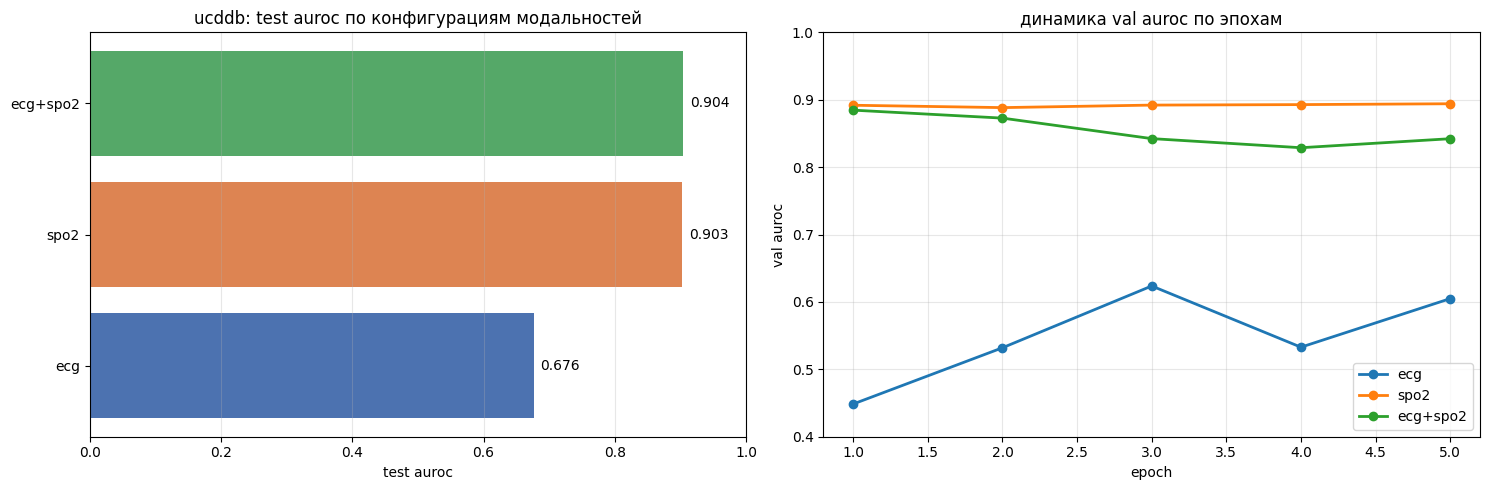

график сохранён: artifacts/claude_ucddb_multimodal.png



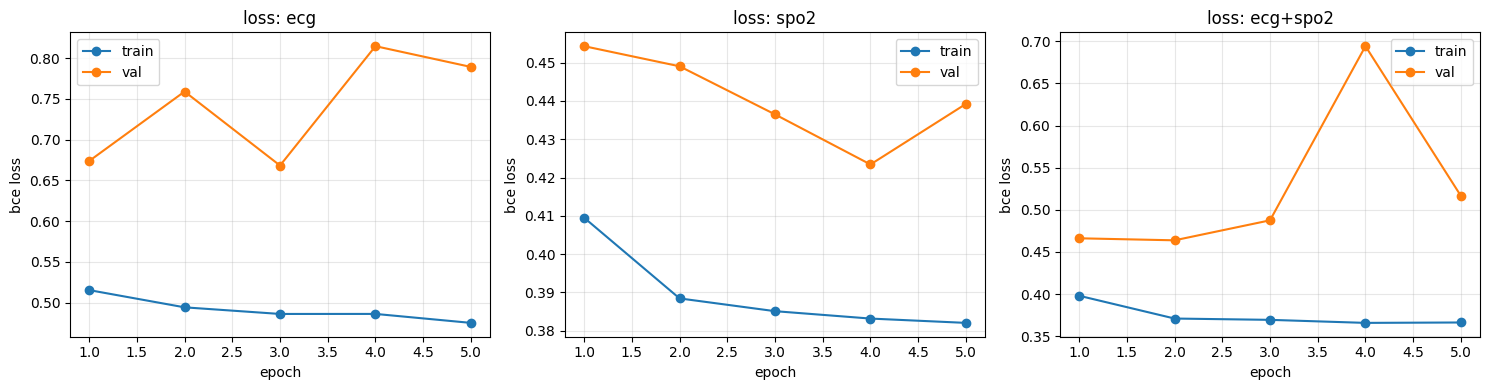

loss-кривые сохранены: artifacts/claude_ucddb_loss_curves.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_plot = cl_results_df.sort_values("test_auroc", ascending=True)
colors = ["#4c72b0", "#dd8452", "#55a868"][:len(df_plot)]
bars = axes[0].barh(df_plot["modalities"], df_plot["test_auroc"], color=colors)
axes[0].set_xlabel("test auroc")
axes[0].set_title("ucddb: test auroc по конфигурациям модальностей")
axes[0].grid(True, axis="x", alpha=0.3)
axes[0].set_xlim(0, 1.0)
for i, v in enumerate(df_plot["test_auroc"]):
    if not np.isnan(v):
        axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)

for key, hist in cl_histories.items():
    if "val_auroc" in hist.columns:
        axes[1].plot(hist["epoch"], hist["val_auroc"], marker="o", label=key, linewidth=2)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val auroc")
axes[1].set_title("динамика val auroc по эпохам")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_ylim(0.4, 1.0)

plt.tight_layout()
png_path = Path(cfg.artifacts_dir) / "claude_ucddb_multimodal.png"
plt.savefig(png_path, dpi=120, bbox_inches="tight")
plt.show()

print(f"график сохранён: {png_path}")
print()

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, hist) in zip(axes2, cl_histories.items()):
    if "train_loss" in hist.columns and "val_loss" in hist.columns:
        ax.plot(hist["epoch"], hist["train_loss"], marker="o", label="train")
        ax.plot(hist["epoch"], hist["val_loss"], marker="o", label="val")
        ax.set_title(f"loss: {key}")
        ax.set_xlabel("epoch")
        ax.set_ylabel("bce loss")
        ax.grid(True, alpha=0.3)
        ax.legend()
plt.tight_layout()
loss_png = Path(cfg.artifacts_dir) / "claude_ucddb_loss_curves.png"
plt.savefig(loss_png, dpi=120, bbox_inches="tight")
plt.show()
print(f"loss-кривые сохранены: {loss_png}")


In [21]:
print("ключевые цифры для слайда:")
print()
ecg_only = cl_results_df.query("modalities == 'ecg'").iloc[0] if (cl_results_df["modalities"] == "ecg").any() else None
spo2_only = cl_results_df.query("modalities == 'spo2'").iloc[0] if (cl_results_df["modalities"] == "spo2").any() else None
both = cl_results_df.query("modalities == 'ecg+spo2'").iloc[0] if (cl_results_df["modalities"] == "ecg+spo2").any() else None

if ecg_only is not None:
    print(f"  ecg only:       auc={ecg_only['test_auroc']:.3f}  recall={ecg_only['test_recall_apnea']:.3f}  f1={ecg_only['test_f1_apnea']:.3f}")
if spo2_only is not None:
    print(f"  spo2 only:      auc={spo2_only['test_auroc']:.3f}  recall={spo2_only['test_recall_apnea']:.3f}  f1={spo2_only['test_f1_apnea']:.3f}")
if both is not None:
    print(f"  ecg + spo2:     auc={both['test_auroc']:.3f}  recall={both['test_recall_apnea']:.3f}  f1={both['test_f1_apnea']:.3f}")

print()
if both is not None and ecg_only is not None:
    delta_vs_ecg = both["test_auroc"] - ecg_only["test_auroc"]
    print(f"  прирост ecg+spo2 vs ecg:  {delta_vs_ecg:+.3f} auc")
if both is not None and spo2_only is not None:
    delta_vs_spo2 = both["test_auroc"] - spo2_only["test_auroc"]
    print(f"  прирост ecg+spo2 vs spo2: {delta_vs_spo2:+.3f} auc")

print()
print("файлы для отчёта:")
print(f"  csv:        {Path(cfg.artifacts_dir) / 'claude_ucddb_multimodal_results.csv'}")
print(f"  auroc plot: {Path(cfg.artifacts_dir) / 'claude_ucddb_multimodal.png'}")
print(f"  loss plot:  {Path(cfg.artifacts_dir) / 'claude_ucddb_loss_curves.png'}")


ключевые цифры для слайда:

  ecg only:       auc=0.676  recall=0.000  f1=0.000
  spo2 only:      auc=0.903  recall=0.609  f1=0.688
  ecg + spo2:     auc=0.904  recall=0.506  f1=0.630

  прирост ecg+spo2 vs ecg:  +0.228 auc
  прирост ecg+spo2 vs spo2: +0.001 auc

файлы для отчёта:
  csv:        artifacts/claude_ucddb_multimodal_results.csv
  auroc plot: artifacts/claude_ucddb_multimodal.png
  loss plot:  artifacts/claude_ucddb_loss_curves.png
